# Numeric plots for the coherent coupler

In [63]:
from sympy import *

# -- Symbols --

(
    x, y, z, z0, z1, g2, g3, m, n, l, k, i, j, M, N, K, H, n2, C, T, chi, t, upsilon
) = symbols('''x, y, z, z0, z1, g2, g3, m, n, l, k, i, j, M, N, K, H, n2, C, T, chi, t, upsilon''')

# -- Functions --

pw = Function('pw') # Weierstrass P function
pwp = Function('pwp') # Derivative of Weierstrass P function
zw = Function('zw') # Weierstrass Zeta function
sigma = Function('sigma') # Weierstrass Sigma function
zeta = Function('zeta') # Weierstrass Zeta function
wp = Function('wp') # Weierstrass P function
wpp = Function(r"\wp'") # Derivative of Weierstrass P function

u = Function('u')
v = Function('v')
U = Function('U')
V = Function('V')
rho = Function('rho')
s = Function('s')
Q = Function('Q') # Polynomial
Delta = Function('Delta')

A1 = Function('A1')
A2 = Function('A2')
A3 = Function('A3')
A4 = Function('A4')
Ac1 = Function('Ac1')
Ac2 = Function('Ac2')
Ac3 = Function('Ac3')
Ac4 = Function('Ac4')

# -- Canonical coordinate --

uhat = Function('uhat', latex_name=r'\hat{u}')
vhat = Function('vhat', latex_name=r'\hat{v}')
Hhat = Symbol('Hhat', latex_name=r'\hat{H}')

ubar = Function('ubar', latex_name=r'\bar{u}')
vbar = Function('vbar', latex_name=r'\bar{v}')
Hbar = Symbol('Hbar', latex_name=r'\bar{H}')
wbar = Function('wbar', latex_name=r'\bar{w}')

utilde = Function('utilde', latex_name=r'\tilde{u}')
vtilde = Function('vtilde', latex_name=r'\tilde{v}')
Htilde = Symbol('Htilde', latex_name=r'\tilde{H}')
htilde = Function('htilde', latex_name=r'\tilde{h}')
wtilde = Function('wtilde', latex_name=r'\tilde{w}')

gtilde2 = Symbol('gtilde2', latex_name=r'\tilde{g_2}')
gtilde3 = Symbol('gtilde3', latex_name=r'\tilde{g_3}')
gammatilde = IndexedBase('gammatilde', latex_name=r'\tilde{gamma}')
etilde = IndexedBase('etilde', latex_name=r'\tilde{e}')
alphahat = IndexedBase('alphahat', latex_name=r'\hat{\alpha}')


# -- Indexed Symbols --

eta = IndexedBase('eta')
gamma = IndexedBase('gamma')

lam = IndexedBase('lam')
lamda = IndexedBase('lamda')
Lamda = IndexedBase('Lamda')
A = IndexedBase('A')
mu = IndexedBase('mu')
nu = IndexedBase('nu')
a = IndexedBase('a')
b = IndexedBase('b')
c = IndexedBase('c')
d = IndexedBase('d')
r = IndexedBase('r')
alpha = IndexedBase('alpha')
omega = IndexedBase('omega')
f = IndexedBase('f')
fc = IndexedBase('fc')
F = IndexedBase('F')
beta = IndexedBase('beta')

wild = Wild('*')


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# The package containing mpmath expressions for Weierstrass elliptic functions
from weierstrass_modified import Weierstrass
we = Weierstrass()
from mpmath import exp as mpexp
from mpmath import log as mplog


# Numeric solutions to diff eqs
from numpy import (
    linspace, absolute, angle, square, real, imag, conj, array as arraynp, 
    concatenate, real_if_close
)
from numpy import vectorize as np_vectorize # not to get confused with vectorise in other packages
from numpy import log as np_log
import scipy.integrate
import matplotlib.pyplot as plt
from random import random, uniform as random_uniform

import numpy as np # Late on decided to just import it all (got lazy)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
def mpc_to_float(mpc_val):
    return float(mpc_val.real) + float(mpc_val.imag)*1j

mpc_to_float_np = np_vectorize(mpc_to_float)

def random_complex():
    # Generate a random complex number: a + bj
    a = random_uniform(-10, 10)  # real part
    b = random_uniform(-10, 10)  # imaginary part 
    return complex(a, b)

## The general 2 mode system with a quadratic phase modulation polynomial

In [11]:
du_phase_mod_part = (a[j] + Sum(a[j,k]*u(z,mu[k])*v(z,mu[k]), (k,1,2)))*u(z,mu[j])
du_mixing_part = Product(v(z,mu[k]), (k,1,2))/v(z, mu[j])
duj = Eq(diff(u(z,mu[j]),z), -du_phase_mod_part + du_mixing_part)

dv_phase_mod_part = -(a[j] + Sum(a[j,k]*u(z,mu[k])*v(z,mu[k]), (k,1,2)))*v(z,mu[j])
dv_mixing_part = -Product(u(z,mu[k]), (k,1,2))/u(z, mu[j])
dvj = Eq(diff(v(z,mu[j]),z), (-dv_phase_mod_part).factor() + dv_mixing_part)

Quv_eq = Eq(
    Q(u(z, mu[1])*v(z, mu[1]), u(z, mu[2])*v(z, mu[2])),
    a[0] + Sum(a[j]*u(z, mu[j])*v(z, mu[j]), (j,1,2)) + 
    Sum(a[j,k]*u(z, mu[j])*v(z, mu[j])*u(z, mu[k])*v(z, mu[k]), (j,1,2), (j,1,2))
)

# duj
# dvj
# Quv_eq
du_js = [duj.subs(j,_j).doit() for _j in range(1,3)]
dv_js = [dvj.subs(j,_j).doit() for _j in range(1,3)]

for _eq in du_js:
    _eq
    
for _eq in dv_js:
    _eq

Eq(Derivative(u(z, mu[1]), z), -(u(z, mu[1])*v(z, mu[1])*a[1, 1] + u(z, mu[2])*v(z, mu[2])*a[1, 2] + a[1])*u(z, mu[1]) + v(z, mu[2]))

Eq(Derivative(u(z, mu[2]), z), -(u(z, mu[1])*v(z, mu[1])*a[2, 1] + u(z, mu[2])*v(z, mu[2])*a[2, 2] + a[2])*u(z, mu[2]) + v(z, mu[1]))

Eq(Derivative(v(z, mu[1]), z), (u(z, mu[1])*v(z, mu[1])*a[1, 1] + u(z, mu[2])*v(z, mu[2])*a[1, 2] + a[1])*v(z, mu[1]) - u(z, mu[2]))

Eq(Derivative(v(z, mu[2]), z), (u(z, mu[1])*v(z, mu[1])*a[2, 1] + u(z, mu[2])*v(z, mu[2])*a[2, 2] + a[2])*v(z, mu[2]) - u(z, mu[1]))

In [12]:
a_0_init = Eq(
    a[0],
    - Sum(a[j]*u(0,mu[j])*v(0,mu[j]), (j,1,2))
    - Sum(a[j,k]/2*u(0,mu[j])*v(0,mu[j])*u(0,mu[k])*v(0,mu[k]), (j,1,2), (k,1,2))
    + Product(u(0,mu[j]),(j,1,2)) + Product(v(0,mu[j]),(j,1,2))
)

uv_j_rho = Eq(u(z,mu[j])*v(z,mu[j]), gamma[j] - rho(z))
sum_gamma_j_0 = Eq(Sum(gamma[j], (j,1,2)), 0)
rho_z_mean_uv = Eq(rho(z), -Sum(u(z,mu[j])*v(z,mu[j]), (j,1,2))/2)
gamma_j_init = Eq(gamma[j], solve(uv_j_rho, gamma[j])[0].subs(*rho_z_mean_uv.args).subs(z,0))

rho0_eq = Eq(rho(0), -Sum(u(0, mu[j])*v(0, mu[j]), (j, 1, 2))/2)
drho0_eq = Eq(
    Subs(Derivative(rho(z), z), z, 0),
    u(0, mu[1])*u(0, mu[2]) - v(0, mu[1])*v(0, mu[2])
)

a_0_init
uv_j_rho
sum_gamma_j_0
rho_z_mean_uv
gamma_j_init
rho0_eq
drho0_eq

Eq(a[0], Product(u(0, mu[j]), (j, 1, 2)) + Product(v(0, mu[j]), (j, 1, 2)) - Sum(u(0, mu[j])*v(0, mu[j])*a[j], (j, 1, 2)) - Sum(u(0, mu[j])*u(0, mu[k])*v(0, mu[j])*v(0, mu[k])*a[j, k]/2, (j, 1, 2), (k, 1, 2)))

Eq(u(z, mu[j])*v(z, mu[j]), -rho(z) + gamma[j])

Eq(Sum(gamma[j], (j, 1, 2)), 0)

Eq(rho(z), -Sum(u(z, mu[j])*v(z, mu[j]), (j, 1, 2))/2)

Eq(gamma[j], u(0, mu[j])*v(0, mu[j]) - Sum(u(0, mu[j])*v(0, mu[j]), (j, 1, 2))/2)

Eq(rho(0), -Sum(u(0, mu[j])*v(0, mu[j]), (j, 1, 2))/2)

Eq(Subs(Derivative(rho(z), z), z, 0), u(0, mu[1])*u(0, mu[2]) - v(0, mu[1])*v(0, mu[2]))

In [13]:
b_j_coeffs = [
    Eq(
        b[0], 
        (gamma[1] - gamma[2])**2*(Sum(a[j, j]/4, (j, 1, 2)) - Sum(a[j, k]/8, (j, 1, 2), (k, 1, 2))) 
        + a[0] + Sum(a[j]*gamma[j], (j, 1, 2))
    ),
    Eq(b[1], -Sum(a[j, j]*gamma[j], (j, 1, 2)) - Sum(a[j], (j, 1, 2))),
    Eq(b[2], Sum(a[j, k]/2, (j, 1, 2), (k, 1, 2)))
]

c_j_coeffs = [Eq(c[0], Product(gamma[j], (j, 1, 2))), Eq(c[1], 0), Eq(c[2], 1)]


d_j_coeffs = [
    Eq(d[0], b[0]**2 - 4*c[0]),
    Eq(d[1], 2*b[0]*b[1] - 4*c[1]),
    Eq(d[2], 2*b[0]*b[2] + b[1]**2 - 4*c[2]),
    Eq(d[3], 2*b[1]*b[2]),
    Eq(d[4], b[2]**2)
]

Lams = [
    Eq(
        Lamda[0, m],
        -a[m] - gamma[m]*Sum(a[j, k]/4, (j, 1, 2), (k, 1, 2))
        + Sum(a[j, j]*gamma[j], (j, 1, 2))/2 - Sum(a[m, k]*gamma[k], (k, 1, 2)) + Sum(a[j]/2, (j, 1, 2))
    ),
    Eq(Lamda[1, m], Sum(a[m, k], (k, 1, 2)) - Sum(a[j, k]/4, (j, 1, 2), (k, 1, 2)))
]

g2_dj = Eq(g2, d[0]*d[4] - d[1]*d[3]/4 + d[2]**2/12)
g3_dj = Eq(g3, d[0]*d[2]*d[4]/6 - d[0]*d[3]**2/16 - d[1]**2*d[4]/16 + d[1]*d[2]*d[3]/48 - d[2]**3/216)

for _ in b_j_coeffs:
    _
    
for _ in c_j_coeffs:
    _
    
for _ in d_j_coeffs:
    _
    
for _ in Lams:
    _

g2_dj
g3_dj

Eq(b[0], (gamma[1] - gamma[2])**2*(Sum(a[j, j]/4, (j, 1, 2)) - Sum(a[j, k]/8, (j, 1, 2), (k, 1, 2))) + a[0] + Sum(a[j]*gamma[j], (j, 1, 2)))

Eq(b[1], -Sum(a[j, j]*gamma[j], (j, 1, 2)) - Sum(a[j], (j, 1, 2)))

Eq(b[2], Sum(a[j, k]/2, (j, 1, 2), (k, 1, 2)))

Eq(c[0], Product(gamma[j], (j, 1, 2)))

Eq(c[1], 0)

...

Eq(d[4], b[2]**2)

Eq(Lamda[0, m], -a[m] - gamma[m]*Sum(a[j, k]/4, (j, 1, 2), (k, 1, 2)) + Sum(a[j, j]*gamma[j], (j, 1, 2))/2 - Sum(a[m, k]*gamma[k], (k, 1, 2)) + Sum(a[j]/2, (j, 1, 2)))

Eq(Lamda[1, m], Sum(a[m, k], (k, 1, 2)) - Sum(a[j, k]/4, (j, 1, 2), (k, 1, 2)))

Eq(g2, d[0]*d[4] - d[1]*d[3]/4 + d[2]**2/12)

Eq(g3, d[0]*d[2]*d[4]/6 - d[0]*d[3]**2/16 - d[1]**2*d[4]/16 + d[1]*d[2]*d[3]/48 - d[2]**3/216)

In [14]:
d_poly_lam = Eq(d[0] + d[1]*lam[1] + d[2]*lam[1]**2 + d[3]*lam[1]**3 + d[4]*lam[1]**4, 0)

wp_z0_eq = Eq(
    wp(z0, g2, g3),
    d[2]/12 + d[3]*lam[1]/4 + d[4]*lam[1]**2/2 + 
    (-d[1] - 2*d[2]*lam[1] - 3*d[3]*lam[1]**2 - 4*d[4]*lam[1]**3)/(4*(-rho(0) + lam[1]))
)
wpp_z0_eq = Eq(
    wpp(z0, g2, g3),
    (d[1] + 2*d[2]*lam[1] + 3*d[3]*lam[1]**2 + 4*d[4]*lam[1]**3)*
    Subs(Derivative(rho(z), z), z, 0)/(4*(rho(0) - lam[1])**2)
)

wp_z1_eq = Eq(
    wp(z1, g2, g3), 
    d[2]/12 + d[3]*lam[1]/4 + d[4]*lam[1]**2/2
)
wpp_z1_eq = Eq(
    wpp(z1, g2, g3), 
    (-d[1] - 2*d[2]*lam[1] - 3*d[3]*lam[1]**2 - 4*d[4]*lam[1]**3)*sqrt(d[4])/4
)

wp_z0_muj_eq = Eq(
    wp(-z0 + mu[j], g2, g3),
    d[2]/12 + d[3]*lam[1]/4 + d[4]*lam[1]**2/2 - 
    (-d[1] - 2*d[2]*lam[1] - 3*d[3]*lam[1]**2 - 4*d[4]*lam[1]**3)/(4*(gamma[j] - lam[1]))
)

wpp_z0_muj_eq = Eq(
    wpp(-z0 + mu[j], g2, g3),
    -(b[0] + b[1]*gamma[j] + b[2]*gamma[j]**2)*
    (d[1] + 2*d[2]*lam[1] + 3*d[3]*lam[1]**2 + 4*d[4]*lam[1]**3)/(4*(gamma[j] - lam[1])**2)
)


d_poly_lam
wp_z1_eq
wpp_z1_eq
wp_z0_eq
wpp_z0_eq
wp_z0_muj_eq
wpp_z0_muj_eq

Eq(d[0] + d[1]*lam[1] + d[2]*lam[1]**2 + d[3]*lam[1]**3 + d[4]*lam[1]**4, 0)

Eq(wp(z1, g2, g3), d[2]/12 + d[3]*lam[1]/4 + d[4]*lam[1]**2/2)

Eq(\wp'(z1, g2, g3), (-d[1] - 2*d[2]*lam[1] - 3*d[3]*lam[1]**2 - 4*d[4]*lam[1]**3)*sqrt(d[4])/4)

Eq(wp(z0, g2, g3), d[2]/12 + d[3]*lam[1]/4 + d[4]*lam[1]**2/2 + (-d[1] - 2*d[2]*lam[1] - 3*d[3]*lam[1]**2 - 4*d[4]*lam[1]**3)/(-4*rho(0) + 4*lam[1]))

Eq(\wp'(z0, g2, g3), (d[1] + 2*d[2]*lam[1] + 3*d[3]*lam[1]**2 + 4*d[4]*lam[1]**3)*Subs(Derivative(rho(z), z), z, 0)/(4*(rho(0) - lam[1])**2))

Eq(wp(-z0 + mu[j], g2, g3), d[2]/12 + d[3]*lam[1]/4 + d[4]*lam[1]**2/2 - (-d[1] - 2*d[2]*lam[1] - 3*d[3]*lam[1]**2 - 4*d[4]*lam[1]**3)/(4*gamma[j] - 4*lam[1]))

Eq(\wp'(-z0 + mu[j], g2, g3), (-b[0] - b[1]*gamma[j] - b[2]*gamma[j]**2)*(d[1] + 2*d[2]*lam[1] + 3*d[3]*lam[1]**2 + 4*d[4]*lam[1]**3)/(4*(gamma[j] - lam[1])**2))

In [15]:
r012s = [
    Eq(
        r[0, j],
        -2*zeta(z1, g2, g3)*Lamda[1, j]/sqrt(d[4])
        - zeta(-z0 - z1 + mu[j], g2, g3)/2 - zeta(-z0 + z1 + mu[j], g2, g3)/2 + Lamda[0, j] + Lamda[1, j]*lamda[1]
    ),
    Eq(r[1, j], Lamda[1, j]/sqrt(d[4])),
    Eq(r[2, j], Lamda[1, j]/sqrt(d[4]) - Rational(1,2))
]
for _ in r012s:
    _

Eq(r[0, j], -2*zeta(z1, g2, g3)*Lamda[1, j]/sqrt(d[4]) - zeta(-z0 - z1 + mu[j], g2, g3)/2 - zeta(-z0 + z1 + mu[j], g2, g3)/2 + Lamda[0, j] + Lamda[1, j]*lamda[1])

Eq(r[1, j], Lamda[1, j]/sqrt(d[4]))

Eq(r[2, j], Lamda[1, j]/sqrt(d[4]) - 1/2)

In [16]:
uz_sol = Eq(
    u(z, mu[j]),
    alpha[j]*d[4]**Rational(-1, 4)*
    sqrt(wpp(z1, g2, g3))/
    sqrt((wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3)))/
    sqrt(wp(z1, g2, g3) - wp(z - z0, g2, g3))
    *sigma(z - 2*z0 + mu[j], g2, g3)/(sigma(z - z0, g2, g3)*sigma(-z0 + mu[j], g2, g3))
    *exp(z*r[0, j] + log(sigma(z - z0 + z1, g2, g3)/sigma(z - z0 - z1, g2, g3))*r[1, j])
)
vz_sol = Eq(
    v(z, mu[j]),
    1/alpha[j]*d[4]**Rational(-1, 4)*
    sqrt(wpp(z1, g2, g3))/
    sqrt((wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3)))/
    sqrt(wp(z1, g2, g3) - wp(z - z0, g2, g3))
    *sigma(z - mu[j], g2, g3)/(sigma(z - z0, g2, g3)*sigma(-z0 + mu[j], g2, g3))
    *exp(-z*r[0, j] - log(sigma(z - z0 + z1, g2, g3)/sigma(z - z0 - z1, g2, g3))*r[1, j])
)

uz_sol
vz_sol

Eq(u(z, mu[j]), sqrt(\wp'(z1, g2, g3))*sigma(z - 2*z0 + mu[j], g2, g3)*exp(z*r[0, j] + log(sigma(z - z0 + z1, g2, g3)/sigma(z - z0 - z1, g2, g3))*r[1, j])*alpha[j]/(sqrt(wp(z1, g2, g3) - wp(z - z0, g2, g3))*sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(z - z0, g2, g3)*sigma(-z0 + mu[j], g2, g3)*d[4]**(1/4)))

Eq(v(z, mu[j]), sqrt(\wp'(z1, g2, g3))*sigma(z - mu[j], g2, g3)*exp(-z*r[0, j] - log(sigma(z - z0 + z1, g2, g3)/sigma(z - z0 - z1, g2, g3))*r[1, j])/(sqrt(wp(z1, g2, g3) - wp(z - z0, g2, g3))*sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(z - z0, g2, g3)*sigma(-z0 + mu[j], g2, g3)*alpha[j]*d[4]**(1/4)))

In [17]:
# If u(0, mu[j])!=0, v(0, mu[j])!=0

alpha_u = Eq(
    alpha[j],
    solve(uz_sol.subs(z,0), alpha[j])[0]
)

alpha_v = Eq(
    alpha[j],
    solve(vz_sol.subs(z,0), alpha[j])[0]
)

alpha_u
alpha_v

Eq(alpha[j], sqrt(-wp(-z0, g2, g3) + wp(z1, g2, g3))*sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0, g2, g3)*sigma(-z0 + mu[j], g2, g3)*u(0, mu[j])*exp(-log(sigma(-z0 + z1, g2, g3)/sigma(-z0 - z1, g2, g3))*r[1, j])*d[4]**(1/4)/(sqrt(\wp'(z1, g2, g3))*sigma(-2*z0 + mu[j], g2, g3)))

Eq(alpha[j], sqrt(\wp'(z1, g2, g3))*sigma(-mu[j], g2, g3)*exp(-log(sigma(-z0 + z1, g2, g3)/sigma(-z0 - z1, g2, g3))*r[1, j])/(sqrt(-wp(-z0, g2, g3) + wp(z1, g2, g3))*sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0, g2, g3)*sigma(-z0 + mu[j], g2, g3)*v(0, mu[j])*d[4]**(1/4)))

### Gauge transformed solutions

In [93]:
duhat_dvhats =[
    Eq(
        Derivative(uhat(z, mu[1]), z),
        -uhat(z, mu[1])**2*vhat(z, mu[1])*b[2] + uhat(z, mu[1])*b[1]/2 + vhat(z, mu[2])
    ),
    Eq(
        Derivative(uhat(z, mu[2]), z),
        -uhat(z, mu[2])**2*vhat(z, mu[2])*b[2] + uhat(z, mu[2])*b[1]/2 + vhat(z, mu[1])
    ),
    Eq(
        Derivative(vhat(z, mu[1]), z),
        uhat(z, mu[1])*vhat(z, mu[1])**2*b[2] - uhat(z, mu[2]) - vhat(z, mu[1])*b[1]/2
    ),
    Eq(
        Derivative(vhat(z, mu[2]), z),
        -uhat(z, mu[1]) + uhat(z, mu[2])*vhat(z, mu[2])**2*b[2] - vhat(z, mu[2])*b[1]/2
    )
]

for _ in duhat_dvhats:
    _

Eq(Derivative(uhat(z, mu[1]), z), -uhat(z, mu[1])**2*vhat(z, mu[1])*b[2] + uhat(z, mu[1])*b[1]/2 + vhat(z, mu[2]))

Eq(Derivative(uhat(z, mu[2]), z), -uhat(z, mu[2])**2*vhat(z, mu[2])*b[2] + uhat(z, mu[2])*b[1]/2 + vhat(z, mu[1]))

Eq(Derivative(vhat(z, mu[1]), z), uhat(z, mu[1])*vhat(z, mu[1])**2*b[2] - uhat(z, mu[2]) - vhat(z, mu[1])*b[1]/2)

Eq(Derivative(vhat(z, mu[2]), z), -uhat(z, mu[1]) + uhat(z, mu[2])*vhat(z, mu[2])**2*b[2] - vhat(z, mu[2])*b[1]/2)

In [167]:
uhatz_sol = Eq(
    uhat(z, mu[j]),
    alphahat[j]*sqrt(wpp(z1, g2, g3))*sigma(z1, g2, g3)*sigma(z - 2*z0 + mu[j], g2, g3)
    *exp((-1)**(j+1)*z*beta[0] + z*r[0, j])/
    (
        sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))
        *sigma(-z0 + mu[j], g2, g3)*sigma(z - z0 - z1, g2, g3)*d[4]**Rational(1,4)
    )
)
vhatz_sol = Eq(
    vhat(z, mu[j]),
    1/alphahat[j]*sqrt(wpp(z1, g2, g3))*sigma(z1, g2, g3)*sigma(z - mu[j], g2, g3)
    *exp(-(-1)**(j+1)*z*beta[0] - z*r[0, j])/
    (
        sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))
        *sigma(-z0 + mu[j], g2, g3)*sigma(z - z0 + z1, g2, g3)*d[4]**Rational(1,4)
    )
)
alphahat_u_uhat = Eq(
    alphahat[j], 
    solve(Eq(1, (uz_sol.rhs/uhatz_sol.rhs).subs(z,0)), alphahat[j])[0]
#     .subs([
#         (wp(-z0,g2,g3), wp(z0,g2,g3)),
#         (sigma(-z0,g2,g3), -sigma(z0,g2,g3)),
#         (sigma(-z0-z1,g2,g3), -sigma(z0+z1,g2,g3)),
#         (sigma(-z0+z1,g2,g3), -sigma(z0-z1,g2,g3))
#     ])
)

beta0_val = Eq(
    beta[0],
    -(r[1, 1] - r[1, 2])*(-2*zeta(z1, g2, g3) + b[2]*gamma[1] + b[2]*lamda[1])/2
    - 2*a[1, 2]*gamma[1] - a[2] - b[1]/2
)


# Checks
sigma_p_identity = Eq(
    wp(y, g2, g3) - wp(x, g2, g3),
    sigma(x + y, g2, g3) * sigma(x - y, g2, g3) / (sigma(x, g2, g3) ** 2 * sigma(y, g2, g3) ** 2) 
)
u0_ratio_check = Eq(
    uz_sol.lhs.subs(z,0)/uhatz_sol.lhs.subs(z,0), 
    (uz_sol.rhs.subs(z,0)/uhatz_sol.rhs.subs(z,0))
    .subs([alphahat_u_uhat.args])
)
v0_ratio_check = Eq(
    vz_sol.lhs.subs(z,0)/vhatz_sol.lhs.subs(z,0), 
    (vz_sol.rhs.subs(z,0)/vhatz_sol.rhs.subs(z,0))
    .subs([alphahat_u_uhat.args])
    .subs([sigma_p_identity.subs([(y, z1), (x, -z0)]).args])
)
assert u0_ratio_check.rhs == 1
assert v0_ratio_check.rhs == 1


uhatz_sol
vhatz_sol
alphahat_u_uhat
beta0_val

Eq(uhat(z, mu[j]), sqrt(\wp'(z1, g2, g3))*sigma(z1, g2, g3)*sigma(z - 2*z0 + mu[j], g2, g3)*exp((-1)**(j + 1)*z*beta[0] + z*r[0, j])*alphahat[j]/(sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0 + mu[j], g2, g3)*sigma(z - z0 - z1, g2, g3)*d[4]**(1/4)))

Eq(vhat(z, mu[j]), sqrt(\wp'(z1, g2, g3))*sigma(z1, g2, g3)*sigma(z - mu[j], g2, g3)*exp(-(-1)**(j + 1)*z*beta[0] - z*r[0, j])/(sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0 + mu[j], g2, g3)*sigma(z - z0 + z1, g2, g3)*alphahat[j]*d[4]**(1/4)))

Eq(alphahat[j], sigma(-z0 - z1, g2, g3)*exp(log(sigma(-z0 + z1, g2, g3)/sigma(-z0 - z1, g2, g3))*r[1, j])*alpha[j]/(sqrt(-wp(-z0, g2, g3) + wp(z1, g2, g3))*sigma(-z0, g2, g3)*sigma(z1, g2, g3)))

Eq(beta[0], (-r[1, 1] + r[1, 2])*(-2*zeta(z1, g2, g3) + b[2]*gamma[1] + b[2]*lamda[1])/2 - 2*a[1, 2]*gamma[1] - a[2] - b[1]/2)

## Utility functions for numerically evaluating the analytic solutions for $u,v$

In [18]:
def get_init_cons_params(
    u_v_0_init_vals: list[tuple],
    a_params: list[tuple]
) -> dict:

    ## -- Derive intermediate params --
    ## --------------------------------
    
    _init_uv_vals_params  = u_v_0_init_vals + a_params
    
    # - Calculate a[0] (Hamiltonian) -
    a_0_init_val = a_0_init.doit().subs(u_v_0_init_vals + a_params).simplify()
    _init_uv_vals_params += [a_0_init_val.args]
    
    # - Calculate gamma vals -
    _gamma_vals = [
        gamma_j_init.subs(j, _j).doit().subs(u_v_0_init_vals).simplify() 
        for _j in range(1,3)
    ]
    _init_uv_vals_params += [_.args for _ in _gamma_vals]

    # - Calculate bj vals -
    _bj_vals = [ _eq.doit().subs(_init_uv_vals_params).simplify() for _eq in b_j_coeffs]
    _init_uv_vals_params += [_.args for _ in _bj_vals]

    # - Calculate cj vals -
    _cj_vals = [ _eq.doit().subs(_init_uv_vals_params).simplify() for _eq in c_j_coeffs]
    _init_uv_vals_params += [_.args for _ in _cj_vals]

    # - Calculate dj vals -
    _dj_vals = [ _eq.doit().subs(_init_uv_vals_params).simplify() for _eq in d_j_coeffs]
    _init_uv_vals_params += [_.args for _ in _dj_vals]

    # - Calculate root lam[1] -
    _lam1_val = Eq(lam[1], solve(d_poly_lam.subs(_init_uv_vals_params), lam[1])[0])
    _init_uv_vals_params += [_lam1_val.args]
    
    # - Derive Lam[0,j], Lam[1,j] -
    _Lam0s = [Lams[0].subs(m,_j).doit().subs(_init_uv_vals_params).simplify() for _j in range(1,3)]
    _Lam1s = [Lams[1].subs(m,_j).doit().subs(_init_uv_vals_params).simplify() for _j in range(1,3)]
    
    # - Combine params -
    _params = _bj_vals + _cj_vals + _dj_vals + _gamma_vals + _Lam0s + _Lam1s + [a_0_init_val, _lam1_val]
    

    ## -- Derive invariants g2, g3 --
    ## ------------------------------
    
    _g2_val = g2_dj.subs(_init_uv_vals_params).simplify()
    _g3_val = g3_dj.subs(_init_uv_vals_params).simplify()
    _init_uv_vals_params += [_g2_val.args, _g3_val.args]
    

    ## -- Derive the values of the Weierstrass function to be inverted --
    ## ------------------------------------------------------------------
    
    # - Calculate wp, wpp values for z0 and z1 -

    _wp_val_eqs = [
        Eq(
            _eq.lhs, 
            _eq.rhs
            .subs([rho0_eq.args, drho0_eq.args])
            .doit().subs(u_v_0_init_vals)
            .subs(_init_uv_vals_params).simplify()
        )
        for _eq in [wp_z0_eq, wpp_z0_eq, wp_z1_eq, wpp_z1_eq]
    ]

    # - Calculate wp, wpp values for -z0 + mu[j] -

    _wp_z0_mujs = [
        Eq(
            wp_z0_muj_eq.lhs.subs(j,_j), 
            wp_z0_muj_eq.rhs.subs(j,_j)
            .subs(_init_uv_vals_params).simplify()
        ) 
        for _j in range(1,3)
    ]
    _wpp_z0_mujs = [
        Eq(
            wpp_z0_muj_eq.lhs.subs(j,_j), 
            wpp_z0_muj_eq.rhs.subs(j,_j)
            .subs(_init_uv_vals_params).simplify()
        )
        for _j in range(1,3)
    ]

    
    return {
        
        'params': _params,
        'invariants': [
            _g2_val,
            _g3_val
        ],
        'weierstrass_z0': [
            _wp_val_eqs[0],
            _wp_val_eqs[1]
        ],
        'weierstrass_z1': [
            _wp_val_eqs[2],
            _wp_val_eqs[3]
        ],
        'weierstrass_mu_j': _wp_z0_mujs,
        'weierstrass_prime_mu_j': _wpp_z0_mujs
        
    }

In [19]:
def get_error(val1, val2, small_val_threshold=1e-12):
    if abs(val2) >  small_val_threshold:
        return (2 * abs(val1 - val2) / abs(val1 + val2))
    else:
        return abs(val1 - val2)

def get_lattice_and_weierstrass_args(
    init_cons_params: dict,
    _wp_tolerance = 1e-13,
    _wpp_tolerance = 1e-10,
    _small_wpp_threshold = 1e-10
):
    
    # Calculate lattice of elliptic functions (half-periods) in terms of initial conditions
    _g2_val_eq = Eq(g2, g2.subs([_eq.args for _eq in init_cons_params['invariants']]))
    _g3_val_eq = Eq(g3, g3.subs([_eq.args for _eq in init_cons_params['invariants']]))
    
    _omega_ = we.omega_from_g(_g2_val_eq.rhs, _g3_val_eq.rhs)
    _omega1_ = mpc_to_float(_omega_[0])
    _omega2_ = mpc_to_float(_omega_[1])
    _omega3_ = mpc_to_float(_omega_[2])
    if im(_omega2_/_omega1_) <= 0:
        _omega2_ = -_omega2_
    if im(_omega3_/_omega1_) <= 0:
        _omega3_ = -_omega3_
    _omegas = (_omega1_, _omega2_) 

    # Calculate complex constants in the z plane in terms of initial conditions 
    # via inverse Weierstrass P (elliptic integral)
    _input_z0_wp_val = init_cons_params['weierstrass_z0'][0].rhs
    _input_z0_wp_prime_val = init_cons_params['weierstrass_z0'][1].rhs
    _z0_val = mpc_to_float(we.invwp(
        _input_z0_wp_val, 
        _omegas, 
        _input_z0_wp_prime_val
    ))
    
    _input_z1_wp_val = init_cons_params['weierstrass_z1'][0].rhs
    _input_z1_wp_prime_val = init_cons_params['weierstrass_z1'][1].rhs
    _z1_val = mpc_to_float(we.invwp(
        _input_z1_wp_val, 
        _omegas, 
        _input_z1_wp_prime_val
    ))

    _mu_j_vals = [
        (
            _z0_val + 
            mpc_to_float(we.invwp(
                init_cons_params['weierstrass_mu_j'][_j].rhs, 
                _omegas, 
                init_cons_params['weierstrass_prime_mu_j'][_j].rhs
            ))
        )
        for _j in range(2)
    ]

    # Check that the arguments reproduce the values for wp, wpp from which they were derived
    _wp_check_vals = [
        get_error(
            we.wp(_mu_j_vals[_j] - _z0_val, _omegas), 
            init_cons_params['weierstrass_mu_j'][_j].rhs
        )
        for _j in range(2)
    ]
    _wp_check_vals.append(
        get_error(
            we.wp(_z0_val, _omegas),
            _input_z0_wp_val
        )
    )
    _wp_check_vals.append(get_error(we.wp(_z1_val, _omegas), _input_z1_wp_val))
    for i, check_val in enumerate(_wp_check_vals):
        if check_val > _wp_tolerance:
            raise ValueError(f'wp check failed on check {i}: {check_val} > {_wp_tolerance}')

    _wpp_check_vals = [
        get_error(
            we.wpprime(_mu_j_vals[_j] - _z0_val, _omegas),
            init_cons_params['weierstrass_prime_mu_j'][_j].rhs
        )
        for _j in range(2)
    ]
    _wpp_check_vals.append(get_error(we.wpprime(_z0_val, _omegas), _input_z0_wp_prime_val))
    _wpp_check_vals.append(get_error(we.wpprime(_z1_val, _omegas), _input_z1_wp_prime_val))
        
    for i, check_val in enumerate(_wpp_check_vals):
        if check_val > _wpp_tolerance:
            raise ValueError(f'wpp check failed on check {i}: {check_val} > {_wpp_tolerance}')
            
    return {
        "z0": Eq(z0, _z0_val),
        "z1": Eq(z1, _z1_val),
        "omegas": [Eq(omega[_j + 1], _v) for _j, _v in enumerate([_omega1_, _omega2_, _omega3_])],
        "mujs": [Eq(mu[_j + 1], _v) for _j, _v in enumerate(_mu_j_vals)]
    }

In [20]:
def checks( 
    u_v_0_init_vals: dict,
    init_cons_params: dict,
    lattice_and_weierstrass_args: dict,
    unity_check_tolerance=1e-13
):
    _z0 = complex(lattice_and_weierstrass_args["z0"].rhs)
    _z1 = complex(lattice_and_weierstrass_args["z1"].rhs)
    _param_subs = [_eq.args for _eq in init_cons_params["params"]]
    _sqrtd4 = complex(sqrt(d[4]).subs(_param_subs))
    _fourth_root_d4 = complex((d[4]**(Rational(1,4))).subs(_param_subs))
    _omega_subs = [_eq.args for _eq in lattice_and_weierstrass_args["omegas"]]
    _omega1 = complex(Eq(omega[1], omega[1].subs(_omega_subs)).rhs)
    _omega2 = complex(Eq(omega[2], omega[2].subs(_omega_subs)).rhs)
    _omegas = (_omega1, _omega2)
    _mu_j_vals = [complex(_eq.rhs) for _eq in lattice_and_weierstrass_args["mujs"]]
    
    
    unity_vals = [
        abs((
            1 -
            (-we.wp(_z0, _omegas) + we.wp(_z1, _omegas))
            *(we.wp(_z1, _omegas) - we.wp(-_z0 + _mu_j_vals[_j], _omegas))
            *(u(0, mu[_j+1])*v(0, mu[_j+1])).subs(u_v_0_init_vals)*_sqrtd4/
            ((-we.wp(_z0, _omegas) + we.wp(-_z0 + _mu_j_vals[_j], _omegas))*we.wpprime(_z1, _omegas))
        ).evalf())
        for _j in range(2)
    ]
    for _val in unity_vals:
        if _val > unity_check_tolerance:
            raise ValueError(f'unity_check_tolerance failed: {_val} > {unity_check_tolerance}')
    print('Unity checks passed')

In [21]:
def get_alpha_offsets(
    u_v_0_init_vals: dict,
    init_cons_params: dict,
    lattice_and_weierstrass_args: dict,
    zeta_strategy=False,
    v0_only_strategy=False,
    abs_err_tolerance=1e-12
):
    _z0 = complex(lattice_and_weierstrass_args["z0"].rhs)
    _z1 = complex(lattice_and_weierstrass_args["z1"].rhs)
    _param_subs = [_eq.args for _eq in init_cons_params["params"]]
    _sqrtd4 = complex(sqrt(d[4]).subs(_param_subs))
    _fourth_root_d4 = complex((d[4]**(Rational(1,4))).subs(_param_subs))
    _omega_subs = [_eq.args for _eq in lattice_and_weierstrass_args["omegas"]]
    _omega1 = complex(Eq(omega[1], omega[1].subs(_omega_subs)).rhs)
    _omega2 = complex(Eq(omega[2], omega[2].subs(_omega_subs)).rhs)
    _omegas = (_omega1, _omega2)
    _mu_j_vals = [complex(_eq.rhs) for _eq in lattice_and_weierstrass_args["mujs"]]
    
    
    
    if zeta_strategy:
        raise NotImplementedError
#         # Use this if can't use u(0), v(0) strategy because e.g., u(0)=0
#         _epsilon_j_eqs  = [
#             Eq(epsilon[_j+1], _z0*we.wzeta(_mu_j_vals[_j] - _z0, _omegas))
#             for _j in range(3)
#         ]
#         return {
#             'epsilon_j_u0_vals': _epsilon_j_eqs,
#             'epsilon_j_v0_vals': _epsilon_j_eqs
#         }

#     if (not zeta_strategy) and (not v0_only_strategy):
#         raise NotImplementedError
#         _epsilon_j_u0_over_v0_vals = [
#             Eq(
#                 epsilon[_j + 1], 
#                 log(
#                     (
#                         we.wsigma(_mu_j_vals[_j], _omegas)*u(0, mu[_j + 1]).subs(u_v_0_init_vals)/
#                         (we.wsigma(2*_z0 - _mu_j_vals[_j], _omegas)*v(0, mu[_j + 1]).subs(u_v_0_init_vals))*
#                         exp(
#                             -2*log(we.wsigma(_z0 - _z1, _omegas)/we.wsigma(_z0 + _z1, _omegas))*
#                             Lam[1, _j + 1].subs(_param_subs)/_sqrtd4
#                         )
#                     ).expand().evalf()
#                 )/2
#             )
#             for _j in range(4)
#         ]
        
    
# (alpha[j],
#  sqrt(\wp'(z1, g2, g3))*sigma(-mu[j], g2, g3)/sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))
#       *exp(-log(sigma(-z0 + z1, g2, g3)/sigma(-z0 - z1, g2, g3))*r[1, j])
#       /(
#           sqrt(-wp(-z0, g2, g3) + wp(z1, g2, g3))
#           *sigma(-z0, g2, g3)*sigma(-z0 + mu[j], g2, g3)*v(0, mu[j])*d[4]**(1/4)
#       )
#      )
    
    # u(0), v(0) strategy

    _alpha_j_v0_vals = [
        Eq(
            alpha[_j + 1], 
            (
                sqrt(we.wpprime(_z1, _omegas))/
                sqrt(we.wp(_z1, _omegas) - we.wp(-_z0 + _mu_j_vals[_j], _omegas))/
                sqrt(we.wp(_z1, _omegas) - we.wp(_z0, _omegas))*
                we.wsigma(-_mu_j_vals[_j], _omegas)*
                exp(
                    -log(we.wsigma(_z0 - _z1, _omegas)/we.wsigma(_z0 + _z1, _omegas))*
                    (Lamda[1, _j + 1]/_sqrtd4).subs(_param_subs)
                )/(
                    we.wsigma(-_z0, _omegas)*we.wsigma(-_z0 + _mu_j_vals[_j], _omegas)*
                    v(0, mu[_j + 1]).subs(u_v_0_init_vals)*_fourth_root_d4
                )
            ).expand().evalf()
        )
        for _j in range(2)
    ]
    if v0_only_strategy:
        return {
            'alpha_j_u0_vals': _alpha_j_v0_vals,
            'alpha_j_v0_vals': _alpha_j_v0_vals
        }
        
        
# (alpha[j],
#  sqrt(-wp(-z0, g2, g3) + wp(z1, g2, g3))
#  *sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0, g2, g3)*sigma(-z0 + mu[j], g2, g3)
#  *u(0, mu[j])*exp(-log(sigma(-z0 + z1, g2, g3)/sigma(-z0 - z1, g2, g3))*r[1, j])*d[4]**(1/4)/
#  (sqrt(\wp'(z1, g2, g3))*sigma(-2*z0 + mu[j], g2, g3)))
    
    _alpha_j_u0_vals = [
        Eq(
            alpha[_j + 1], 
            (
                sqrt(we.wp(_z1, _omegas) - we.wp(_z0, _omegas))*
                sqrt(we.wp(_z1, _omegas) - we.wp(-_z0 + _mu_j_vals[_j], _omegas))*
                we.wsigma(-_z0, _omegas)*we.wsigma(-_z0 + _mu_j_vals[_j], _omegas)*
                u(0, mu[_j + 1]).subs(u_v_0_init_vals)*_fourth_root_d4*
                exp(
                    -log(we.wsigma(_z0 - _z1, _omegas)/we.wsigma(_z0 + _z1, _omegas))*
                    (Lamda[1, _j + 1]/_sqrtd4).subs(_param_subs)
                )/(
                    sqrt(we.wpprime(_z1, _omegas))*
                    we.wsigma(-2*_z0 + _mu_j_vals[_j], _omegas)
                )
            ).expand().evalf()
        )
        for _j in range(2)
    ]
    
    for _ in _alpha_j_u0_vals:
        print(_)
            
    # Check the values obtained from u0 and v0 agree with each other
    for _i in range(2):
        _u_min_v_abs_err = abs(_alpha_j_u0_vals[_i].rhs - _alpha_j_v0_vals[_i].rhs)
        if _u_min_v_abs_err > abs_err_tolerance:
            raise ValueError(f'_u_min_v_abs_err check failed: {_u_min_v_abs_err} > {abs_err_tolerance}')
        
    return {
        'alpha_j_u0_vals': _alpha_j_u0_vals,
        'alpha_j_v0_vals': _alpha_j_v0_vals
    }

In [22]:
def kron_weierstrass_sigma(
    _z0, _z1, _mu_j, _d_4, _Lam_0_j, _Lam_1_j, _lam_1, _alpha_j, _omegas, conj=False
):
    """
    Modified Kronecker theta function solution
    """
    try:
        _z0 = complex(_z0.evalf())
    except:
        pass
    try:
        _z1 = complex(_z1.evalf())
    except:
        pass
    try:
        _mu_j = complex(_mu_j.evalf())
    except:
        pass
    try:
        _d_4 = complex(_d_4.evalf())
    except:
        pass
    try:
        _Lam_0_j = complex(_Lam_0_j.evalf())
    except:
        pass
    try:
        _Lam_1_j = complex(_Lam_1_j.evalf())
    except:
        pass
    try:
        _lam_1 = complex(_lam_1.evalf())
    except:
        pass
    try:
        _alpha_j = complex(_alpha_j.evalf())
    except:
        pass
    try:
        _omegas = (complex(_omegas[0].evalf()), complex(_omegas[1].evalf()))
    except:
        pass

    _r_0_j = (
        -2*we.wzeta(_z1, _omegas)*_Lam_1_j/sqrt(_d_4) - 
        we.wzeta(-_z0 - _z1 + _mu_j, _omegas)/2 - 
        we.wzeta(-_z0 + _z1 + _mu_j, _omegas)/2 + _Lam_0_j + _Lam_1_j*_lam_1
    )
    _r_1_j = _Lam_1_j/sqrt(_d_4)
    
    _norm_const = (
        we.wpprime(_z1, _omegas)**0.5 / (we.wp(_z1, _omegas) - we.wp(-_z0 + _mu_j, _omegas))**0.5
        / we.wsigma(-_z0 + _mu_j, _omegas) / _d_4**0.25
    )
    
    
    if not conj:
        _norm_const_uj = _norm_const * _alpha_j
        return lambda z: (            
            _norm_const_uj * we.wsigma(z - 2*_z0 + _mu_j, _omegas)
            / (we.wp(_z1, _omegas) - we.wp(z -_z0, _omegas))**0.5
            * mpexp(
                z*_r_0_j + 
                mplog(we.wsigma(z - _z0 + _z1, _omegas)/we.wsigma(z - _z0 - _z1, _omegas))*_r_1_j
            )/
            we.wsigma(z - _z0, _omegas)
        )
    
    _norm_const_vj = _norm_const / _alpha_j
    return lambda z: (  
        _norm_const_vj * we.wsigma(z - _mu_j, _omegas)
        / (we.wp(_z1, _omegas) - we.wp(z -_z0, _omegas))**0.5
        * mpexp(
            - z*_r_0_j
            - mplog(we.wsigma(z - _z0 + _z1, _omegas)/we.wsigma(z - _z0 - _z1, _omegas))*_r_1_j
        )/
        we.wsigma(z - _z0, _omegas)
    )

In [157]:
def kron_weierstrass_sigma_gauge(
    _z0, _z1, _mu_j, _d_4, _Lam_0_j, _Lam_1_j, _lam_1, _alpha_j, _omegas,
    # -- beta0 --
    _Lam_1_js, 
    _a_2,
    _a_1_2,
    _b_1,
    _b_2,
    _gam_1,
    _j,
    # -- 
    conj=False
):
    """
    Modified Kronecker theta function solution after gauge transform
    """

    try:
        _z0 = complex(_z0.evalf())
    except:
        pass
    try:
        _z1 = complex(_z1.evalf())
    except:
        pass
    try:
        _mu_j = complex(_mu_j.evalf())
    except:
        pass
    try:
        _d_4 = complex(_d_4.evalf())
    except:
        pass
    try:
        _Lam_0_j = complex(_Lam_0_j.evalf())
    except:
        pass
    try:
        _Lam_1_j = complex(_Lam_1_j.evalf())
    except:
        pass
    try:
        _lam_1 = complex(_lam_1.evalf())
    except:
        pass
    try:
        _alpha_j = complex(_alpha_j.evalf())
    except:
        pass
    try:
        _omegas = (complex(_omegas[0].evalf()), complex(_omegas[1].evalf()))
    except:
        pass
    
    # beta0
    try:
        _Lam_1_js = [complex(_.evalf()) for _ in _Lam_1_js]
    except:
        pass
    try:
        _a_2 = complex(_a_2.evalf())
    except:
        pass
    try:
        _a_1_2 = complex(_a_1_2.evalf())
    except:
        pass
    try:
        _b_1 = complex(_b_1.evalf())
    except:
        pass
    try:
        _b_2 = complex(_b_2.evalf())
    except:
        pass
    try:
        _gam_1 = complex(_gam_1.evalf())
    except:
        pass
    

    _r_0_j = (
        -2*we.wzeta(_z1, _omegas)*_Lam_1_j/sqrt(_d_4) - 
        we.wzeta(-_z0 - _z1 + _mu_j, _omegas)/2 - 
        we.wzeta(-_z0 + _z1 + _mu_j, _omegas)/2 + _Lam_0_j + _Lam_1_j*_lam_1
    )
    _r_1_j = _Lam_1_j/sqrt(_d_4)
    
    _norm_const = (
        we.wsigma(_z1, _omegas) *
        we.wpprime(_z1, _omegas)**0.5 / (we.wp(_z1, _omegas) - we.wp(-_z0 + _mu_j, _omegas))**0.5
        / we.wsigma(-_z0 + _mu_j, _omegas) / _d_4**0.25
    )
    
    _alpha_hat_j = (
        we.wsigma(_z0 + _z1, _omegas) /
        ( 
            (we.wp(_z1, _omegas) - we.wp(_z0, _omegas))**0.5
            *  we.wsigma(_z0, _omegas) *  we.wsigma(_z1, _omegas)
        ) * mpexp(
            mplog(we.wsigma(- _z0 + _z1, _omegas)/we.wsigma(- _z0 - _z1, _omegas))*_r_1_j
        ) * _alpha_j
    )
    
    # beta0
    _r_1_1 = _Lam_1_js[0]/sqrt(_d_4)
    _r_1_2 = _Lam_1_js[1]/sqrt(_d_4)
    _beta_0 = (
        (-_r_1_1 + _r_1_2) * (- 2 * we.wzeta(_z1, _omegas) + _b_2 * _gam_1 + _b_2 * _lam_1) / 2
        - 2 * _a_1_2 * _gam_1 - _a_2 - _b_1 /2
    )
    
    
    if not conj:
        _norm_const_uj = _norm_const * _alpha_hat_j
        return lambda z: (            
            _norm_const_uj * we.wsigma(z - 2*_z0 + _mu_j, _omegas)
            / we.wsigma(z - _z0 - _z1, _omegas)
            * mpexp(z*_r_0_j + (-1)**(_j + 1.0)*z*_beta_0)
        )
    
    _norm_const_vj = _norm_const / _alpha_hat_j
    return lambda z: (  
        _norm_const_vj * we.wsigma(z - _mu_j, _omegas)
        / we.wsigma(z - _z0 + _z1, _omegas)
        * mpexp(- z*_r_0_j - (-1)**(_j + 1.0)*z*_beta_0)
    )

In [135]:
uhatz_sol
vhatz_sol
alphahat_u_uhat
beta0_val

Eq(uhat(z, mu[j]), sqrt(\wp'(z1, g2, g3))*sigma(z1, g2, g3)*sigma(z - 2*z0 + mu[j], g2, g3)*exp(z*beta[0] + z*r[0, j])*alphahat[j]/(sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0 + mu[j], g2, g3)*sigma(z - z0 - z1, g2, g3)*d[4]**(1/4)))

Eq(vhat(z, mu[j]), sqrt(\wp'(z1, g2, g3))*sigma(z1, g2, g3)*sigma(z - mu[j], g2, g3)*exp(-z*beta[0] - z*r[0, j])/(sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0 + mu[j], g2, g3)*sigma(z - z0 + z1, g2, g3)*alphahat[j]*d[4]**(1/4)))

Eq(alphahat[j], sigma(-z0 - z1, g2, g3)*exp(log(sigma(-z0 + z1, g2, g3)/sigma(-z0 - z1, g2, g3))*r[1, j])*alpha[j]/(sqrt(-wp(-z0, g2, g3) + wp(z1, g2, g3))*sigma(-z0, g2, g3)*sigma(z1, g2, g3)))

Eq(beta[0], (-r[1, 1] + r[1, 2])*(-2*zeta(z1, g2, g3) + b[2]*gamma[1] + b[2]*lamda[1])/2 - 2*a[1, 2]*gamma[1] - a[2] - b[1]/2)

In [23]:
def get_numeric_eval_of_analytic_solution_u_v(
    u_v_0_init_vals: dict,
    a_params: list[tuple],
    init_cons_params: dict,
    lattice_and_weierstrass_args: dict,
    alpha_offsets: dict,
    z_eval_vec: list[float]
):

    _z0 = complex(lattice_and_weierstrass_args["z0"].rhs)
    _z1 = complex(lattice_and_weierstrass_args["z1"].rhs)
    _omega_subs = [_eq.args for _eq in lattice_and_weierstrass_args["omegas"]]
    _omega1 = complex(Eq(omega[1], omega[1].subs(_omega_subs)).rhs)
    _omega2 = complex(Eq(omega[2], omega[2].subs(_omega_subs)).rhs)
    _omegas = (_omega1, _omega2)
    _mu_j_vals = [complex(_eq.rhs) for _eq in lattice_and_weierstrass_args["mujs"]]
    _derived_params = [_eq.args for _eq in init_cons_params['params']]
    
    # Complex valued analytic vector solution (numeric evaluation)
        
    # General quartic case when d4 != 0
    
    _kron_sol_mpmath_us = arraynp([
        mpc_to_float_np(np_vectorize(
            kron_weierstrass_sigma(
                _z0=_z0, 
                _z1=_z1, 
                _mu_j=_mu_j_vals[_j], 
                _d_4=d[4].subs(_derived_params), 
                _Lam_0_j=Lamda[0,_j+1].subs(_derived_params), 
                _Lam_1_j=Lamda[1,_j+1].subs(_derived_params), 
                _lam_1=lam[1].subs(_derived_params), 
                _alpha_j=alpha[_j + 1].subs(*alpha_offsets['alpha_j_u0_vals'][_j].args), 
                _omegas=_omegas, 
                conj=False
            )
        )(z_eval_vec))
        for _j in range(2)
    ], dtype=complex)

    _kron_sol_mpmath_vs = arraynp([
        mpc_to_float_np(np_vectorize(
            kron_weierstrass_sigma(
                _z0=_z0, 
                _z1=_z1, 
                _mu_j=_mu_j_vals[_j], 
                _d_4=d[4].subs(_derived_params), 
                _Lam_0_j=Lamda[0,_j+1].subs(_derived_params), 
                _Lam_1_j=Lamda[1,_j+1].subs(_derived_params), 
                _lam_1=lam[1].subs(_derived_params), 
                _alpha_j=alpha[_j + 1].subs(*alpha_offsets['alpha_j_v0_vals'][_j].args), 
                _omegas=_omegas, 
                conj=True
            )
        )(z_eval_vec))
        for _j in range(2)
    ], dtype=complex)
    
    return {
        'u_j_evals': _kron_sol_mpmath_us,
        'v_j_evals': _kron_sol_mpmath_vs
    }

In [162]:
def get_numeric_eval_of_analytic_solution_uhat_vhat_gauge(
    a_params: dict,
    init_cons_params: dict,
    lattice_and_weierstrass_args: dict,
    alpha_offsets: dict,
    z_eval_vec: list[float]
):

    _z0 = complex(lattice_and_weierstrass_args["z0"].rhs)
    _z1 = complex(lattice_and_weierstrass_args["z1"].rhs)
    _omega_subs = [_eq.args for _eq in lattice_and_weierstrass_args["omegas"]]
    _omega1 = complex(Eq(omega[1], omega[1].subs(_omega_subs)).rhs)
    _omega2 = complex(Eq(omega[2], omega[2].subs(_omega_subs)).rhs)
    _omegas = (_omega1, _omega2)
    _mu_j_vals = [complex(_eq.rhs) for _eq in lattice_and_weierstrass_args["mujs"]]
    _derived_params = [_eq.args for _eq in init_cons_params['params']]
    _a_2 = complex(a_params["a_2"])
    _a_1_2 = complex(a_params["a_1_2"])
    
    # Complex valued analytic vector solution (numeric evaluation)
    
    _kron_sol_mpmath_us = arraynp([
        mpc_to_float_np(np_vectorize(
            kron_weierstrass_sigma_gauge(
                _z0=_z0, 
                _z1=_z1, 
                _mu_j=_mu_j_vals[_j], 
                _d_4=d[4].subs(_derived_params), 
                _Lam_0_j=Lamda[0,_j+1].subs(_derived_params), 
                _Lam_1_j=Lamda[1,_j+1].subs(_derived_params), 
                _lam_1=lam[1].subs(_derived_params), 
                _alpha_j=alpha[_j + 1].subs(*alpha_offsets['alpha_j_u0_vals'][_j].args), 
                _omegas=_omegas, 
                # Extras for beta0
                _Lam_1_js = [Lamda[1,1].subs(_derived_params), Lamda[1,2].subs(_derived_params)],
                _a_2=_a_2,
                _a_1_2=_a_1_2,
                _b_1=b[1].subs(_derived_params),
                _b_2=b[2].subs(_derived_params),
                _gam_1=gamma[1].subs(_derived_params),
                _j=_j+1,
                conj=False
            )
        )(z_eval_vec))
        for _j in range(2)
    ], dtype=complex)

    _kron_sol_mpmath_vs = arraynp([
        mpc_to_float_np(np_vectorize(
            kron_weierstrass_sigma_gauge(
                _z0=_z0, 
                _z1=_z1, 
                _mu_j=_mu_j_vals[_j], 
                _d_4=d[4].subs(_derived_params), 
                _Lam_0_j=Lamda[0,_j+1].subs(_derived_params), 
                _Lam_1_j=Lamda[1,_j+1].subs(_derived_params), 
                _lam_1=lam[1].subs(_derived_params), 
                _alpha_j=alpha[_j + 1].subs(*alpha_offsets['alpha_j_v0_vals'][_j].args), 
                _omegas=_omegas, 
                # Extras for beta0
                _Lam_1_js = [Lamda[1,1].subs(_derived_params), Lamda[1,2].subs(_derived_params)],
                _a_2=_a_2,
                _a_1_2=_a_1_2,
                _b_1=b[1].subs(_derived_params),
                _b_2=b[2].subs(_derived_params),
                _gam_1=gamma[1].subs(_derived_params),
                _j=_j+1,
                conj=True
            )
        )(z_eval_vec))
        for _j in range(2)
    ], dtype=complex)
    
    return {
        'uhat_j_evals': _kron_sol_mpmath_us,
        'vhat_j_evals': _kron_sol_mpmath_vs
    }

## Case 1: Test $u,v$ general solutions

In [24]:
# -- Init values for u, v --

random_uj0s = [ (u(0, mu[_j]), random_complex()*0.1) for _j in range(1, 3)]
random_vj0s = [ (v(0, mu[_j]), random_complex()*0.1) for _j in range(1, 3)]
case1_u_v_0_init_vals = random_uj0s + random_vj0s

# -- Init values for a[j], a[j,k] --

a_1_ind_params = [(a[_j], re(random_complex())*0.1) for _j in range(1, 3)]
a_2_ind_params_matrix = Matrix([[re(random_complex())*0.1 for _j in range(2)]  for _k in range(2)])
a_2_ind_params_matrix = a_2_ind_params_matrix + a_2_ind_params_matrix.T
a_2_ind_params = [(a[_j + 1, _k + 1], a_2_ind_params_matrix[_j,_k]) for _j in range(2) for _k in range(2)]

case1_a_params = a_1_ind_params + a_2_ind_params

In [25]:
# Derive intermediate params, invariants, and weierstrass p values
case1_init_cons_params = get_init_cons_params(
    u_v_0_init_vals=case1_u_v_0_init_vals,
    a_params=case1_a_params
)

for _eq_args in case1_u_v_0_init_vals:
    Eq(*_eq_args)
    
for _eq_args in case1_a_params:
    Eq(*_eq_args)

for _eq in case1_init_cons_params['params']:
    _eq
    
for _eq in case1_init_cons_params['invariants']:
    _eq
    
for _eq in case1_init_cons_params['weierstrass_z0']:
    _eq
    
for _eq in case1_init_cons_params['weierstrass_z1']:
    _eq
    
for _eq in case1_init_cons_params['weierstrass_mu_j']:
    _eq
    
for _eq in case1_init_cons_params['weierstrass_prime_mu_j']:
    _eq

Eq(u(0, mu[1]), -0.671733770129136 + 0.994314642205733*I)

Eq(u(0, mu[2]), 0.324282943946109 - 0.970610226898647*I)

Eq(v(0, mu[1]), -0.307076432311069 - 0.231216521939931*I)

Eq(v(0, mu[2]), -0.496126163286097 - 0.222617735482802*I)

Eq(a[1], -0.949076455759206)

...

Eq(\wp'(z1, g2, g3), 1.15021058331924 + 1.36127348060788*I)

Eq(wp(-z0 + mu[1], g2, g3), 0.000959482280378787 - 0.11061117374696*I)

Eq(wp(-z0 + mu[2], g2, g3), -0.308092247508793 + 0.118313493090138*I)

Eq(\wp'(-z0 + mu[1], g2, g3), 0.178931956106049 + 0.541395831291269*I)

Eq(\wp'(-z0 + mu[2], g2, g3), 0.36045068832104 + 0.174767043311487*I)

In [26]:
case1_lattice_and_weierstrass_args = get_lattice_and_weierstrass_args(
    init_cons_params=case1_init_cons_params,
    _wp_tolerance = 1e-11,
    _wpp_tolerance = 1e-7
)

case1_lattice_and_weierstrass_args["z0"]
case1_lattice_and_weierstrass_args["z1"]
for _eq in case1_lattice_and_weierstrass_args["omegas"]:
    _eq
for _eq in case1_lattice_and_weierstrass_args["mujs"]:
    _eq

Eq(z0, -1.27902045425729 - 1.45094349966762*I)

Eq(z1, -0.991064795826954 + 0.267955767147032*I)

Eq(omega[1], -1.6265475626661 + 0.0266255929639453*I)

Eq(omega[2], 1.24541453269999 - 1.91256150763706*I)

Eq(omega[3], -0.381133029966109 - 1.88593591467312*I)

Eq(mu[1], 0.10091484078867 - 0.332802045708394*I)

Eq(mu[2], -0.676826157649348 - 3.10499648792091*I)

In [27]:
# # Come back and fix this check...

# # Show sum(mu_j + z0,(j,1,2)) = 0 modulo lattice
# sum([
#     _eq.rhs - case1_lattice_and_weierstrass_args["z0"].rhs + 2*case1_lattice_and_weierstrass_args["z1"].rhs
#     for _eq in case1_lattice_and_weierstrass_args["mujs"]
# ])

# _omega_1 = case1_lattice_and_weierstrass_args["omegas"][0]
# _omega_2 = case1_lattice_and_weierstrass_args["omegas"][1]
# _omega_3 = case1_lattice_and_weierstrass_args["omegas"][2]

# 2*_omega_1.rhs
# 2*_omega_2.rhs
# 2*_omega_3.rhs

In [28]:
checks( 
    u_v_0_init_vals=case1_u_v_0_init_vals,
    init_cons_params=case1_init_cons_params,
    lattice_and_weierstrass_args=case1_lattice_and_weierstrass_args,
)

Unity checks passed


In [29]:
case1_alpha_offsets = get_alpha_offsets(
    u_v_0_init_vals=case1_u_v_0_init_vals,
    init_cons_params=case1_init_cons_params,
    lattice_and_weierstrass_args=case1_lattice_and_weierstrass_args
)

for _eq in case1_alpha_offsets['alpha_j_u0_vals']:
    _eq
    
for _eq in case1_alpha_offsets['alpha_j_v0_vals']:
    _eq

Eq(alpha[1], 1.42425006108321 - 2.92569853549922*I)
Eq(alpha[2], 0.134512952149452 + 0.276316889753206*I)


Eq(alpha[1], 1.42425006108321 - 2.92569853549922*I)

Eq(alpha[2], 0.134512952149452 + 0.276316889753206*I)

Eq(alpha[1], 1.42425006108322 - 2.92569853549922*I)

Eq(alpha[2], 0.134512952149451 + 0.276316889753207*I)

In [30]:
# Setup z array to evaluate over based on multiple periods (multiples of 2*omega1)
case1_show_n_periods = 2
case1_z_end = abs(case1_show_n_periods * 2 * complex(case1_lattice_and_weierstrass_args["omegas"][0].rhs))
case1_n_points_z = 500
case1_z_eval = linspace(0, case1_z_end, case1_n_points_z)

# For forcing to real
real_tolerance = 1e5

In [31]:
# Solve differential equations numerically using scipy
case1_eoms = du_js + dv_js
case1_prime_vec = [_eq.rhs.subs(case1_a_params) for _eq in case1_eoms]
case1_u_symbs = [Symbol(f'_u{_j}_symb') for _j in range(1,3)]
case1_v_symbs = [Symbol(f'_v{_j}_symb') for _j in range(1,3)]
case1_u_symb_subs = [(u(z, mu[_j + 1]), case1_u_symbs[_j]) for _j in range(2)]
case1_v_symb_subs = [(v(z, mu[_j + 1]), case1_v_symbs[_j]) for _j in range(2)]
case1_symb_subs = case1_u_symb_subs + case1_v_symb_subs

case1_prime_symb = [_eq.subs(case1_symb_subs) for _eq in case1_prime_vec]
case_1_f_ = lambdify((z, (*case1_u_symbs, *case1_v_symbs)), case1_prime_symb)
case1_init_numeric_only = [float(re(x[1])) + float(im(x[1])) * 1j for x in case1_u_v_0_init_vals]


case1_solution = scipy.integrate.solve_ivp(
    case_1_f_, 
    (0, case1_z_end), 
    case1_init_numeric_only, 
    method='DOP853',        # 8th order method (more accurate than default RK45)
    t_eval=case1_z_eval,
    rtol=1e-10,             # Relative tolerance (default is 1e-3)
    atol=1e-12,             # Absolute tolerance (default is 1e-6)
    max_step=0.1,           # Limit step size (adjust based on z_end scale)
    dense_output=True
)

case1_sol_scipy = case1_solution.y

case1_uv_nums = [
    real_if_close(case1_sol_scipy[_j]*case1_sol_scipy[_j + 2], tol=real_tolerance)
    for _j in range(2)
]
case1_phi_nums = [
    real_if_close(-1.0j/2.0*np_log(case1_sol_scipy[_j]/case1_sol_scipy[_j + 2]), tol=real_tolerance)
    for _j in range(2)
]

case1_scipy_len = len(case1_uv_nums[0])

In [32]:
case1_kron_sol_mpmath = get_numeric_eval_of_analytic_solution_u_v(
    u_v_0_init_vals=case1_u_v_0_init_vals,
    a_params=case1_a_params,
    init_cons_params=case1_init_cons_params,
    lattice_and_weierstrass_args=case1_lattice_and_weierstrass_args,
    alpha_offsets=case1_alpha_offsets,
    z_eval_vec=case1_z_eval
)

case1_uv_ana = [
    real_if_close(
        case1_kron_sol_mpmath['u_j_evals'][_j]*case1_kron_sol_mpmath['v_j_evals'][_j], 
        tol=real_tolerance
    )
    for _j in range(2)
]
case1_phi_ana = [
    real_if_close(
        -1.0j/2.0*np_log(case1_kron_sol_mpmath['u_j_evals'][_j]/case1_kron_sol_mpmath['v_j_evals'][_j]), 
        tol=real_tolerance
    )
    for _j in range(2)
]

case1_ana_len = len(case1_uv_ana[0])

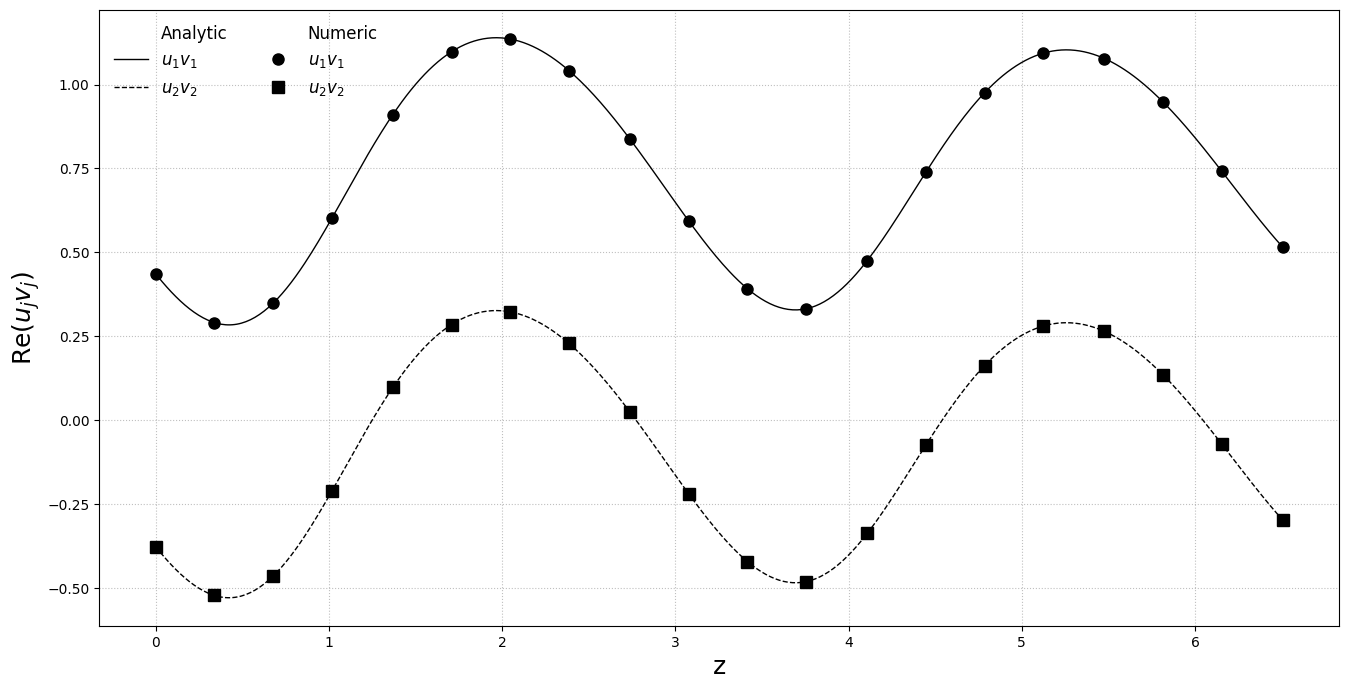

In [33]:
fig = plt.figure(figsize=(16, 8))


# Define markers for the numeric/scipy points
markers = ['o', 's']  # circle, square, triangle, diamond
analytic_linestyles = ['-', '--']   # solid, dashed, dotted, dash-dot

# Analytic plots (black, thin dashed)
case1_uv_ana_lines =[ 
    plt.plot(
        case1_z_eval[0:case1_ana_len],
        np.real(case1_uv_ana[_j]),
        linestyle=analytic_linestyles[_j],
        linewidth=1,
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, we'll handle grouping in legend
    )
    for _j in range(2)
]

# Numeric/scipy plots (black symbols, no lines, spaced out)
num_points = 20  # number of points to plot
indices = np.linspace(0, case1_scipy_len-1, num_points, dtype=int)
case1_uv_num_lines = [
    plt.plot(
        case1_z_eval[indices],
        np.real(case1_uv_nums[_j])[indices],
        linestyle='None',        # no line
        marker=markers[_j],
        markersize=8,            # slightly larger markers for visibility
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, handled in grouped legend
    )
    for _j in range(2)
]

# -------------------------
# Grouped legend
from matplotlib.lines import Line2D

legend_handles = []

# Analytic header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Analytic'))  # header placeholder
for _j, line in enumerate(case1_uv_ana_lines):
    legend_handles.append(Line2D([0], [0], color='black', lw=1, 
                                 linestyle=analytic_linestyles[_j], label=f'$u_{_j+1}v_{_j+1}$'))

# Numeric header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Numeric'))  # header placeholder
for _j, marker in enumerate(markers):
    legend_handles.append(Line2D([0], [0], linestyle='None', marker=marker, color='black', markersize=8,
                                 label=f'$u_{_j+1}v_{_j+1}$'))

case1_legend = plt.legend(handles=legend_handles, fontsize=12, ncol=2, frameon=False)

# Labels and grid (keeping your assignments)
case1_legend = plt.xlabel('z', fontsize=18)
case1_legend = plt.ylabel('$\mathrm{Re}(u_jv_j)$', fontsize=18)
case1_legend = plt.grid(True, linestyle=':', color='gray', alpha=0.5)
# plt.title('Real Parts Analytic vs Numeric Solutions (B&W)')
# plt.show()

# plt.savefig('../latex-papers/fwm-paper/plots/case1_plot_1.pdf', dpi=300, bbox_inches='tight')

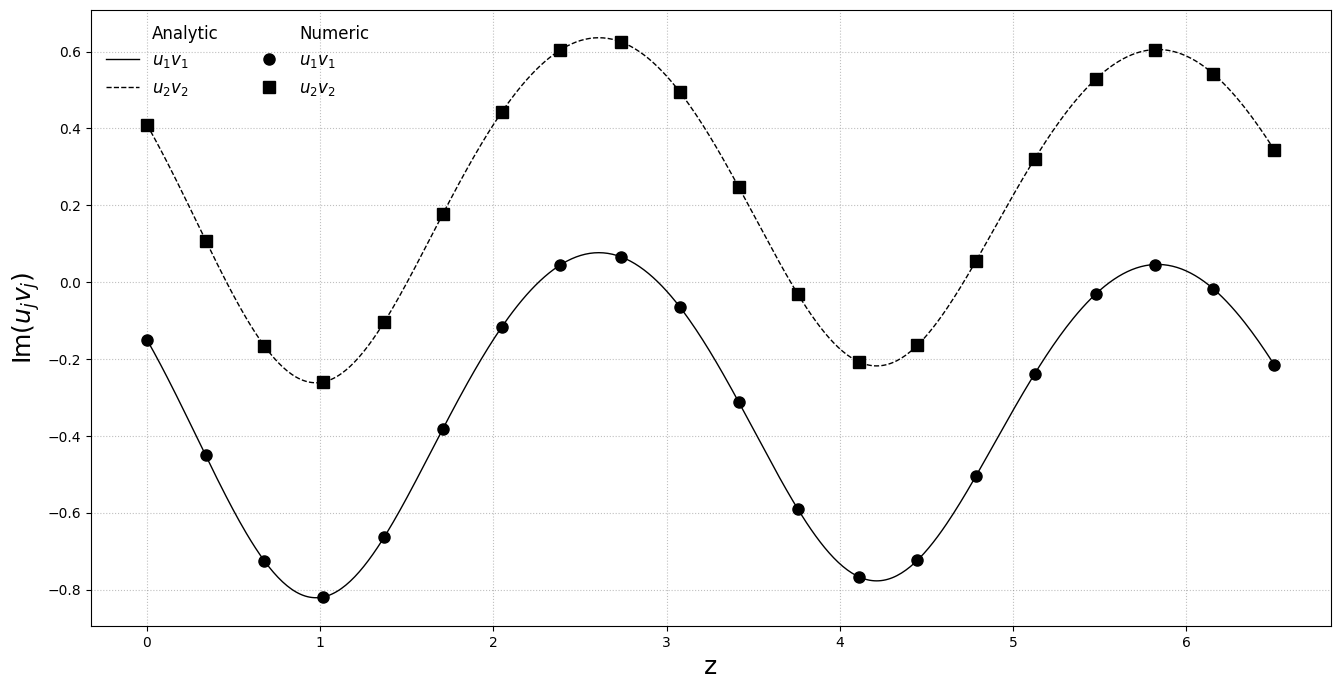

In [34]:
fig = plt.figure(figsize=(16, 8))


# Define markers for the numeric/scipy points
markers = ['o', 's']  # circle, square, triangle, diamond
analytic_linestyles = ['-', '--']   # solid, dashed, dotted, dash-dot

# Analytic plots (black, thin dashed)
case1_uv_ana_lines =[ 
    plt.plot(
        case1_z_eval[0:case1_ana_len],
        np.imag(case1_uv_ana[_j]),
        linestyle=analytic_linestyles[_j],
        linewidth=1,
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, we'll handle grouping in legend
    )
    for _j in range(2)
]

# Numeric/scipy plots (black symbols, no lines, spaced out)
num_points = 20  # number of points to plot
indices = np.linspace(0, case1_scipy_len-1, num_points, dtype=int)
case1_uv_num_lines = [
    plt.plot(
        case1_z_eval[indices],
        np.imag(case1_uv_nums[_j])[indices],
        linestyle='None',        # no line
        marker=markers[_j],
        markersize=8,            # slightly larger markers for visibility
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, handled in grouped legend
    )
    for _j in range(2)
]

# -------------------------
# Grouped legend
from matplotlib.lines import Line2D

legend_handles = []

# Analytic header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Analytic'))  # header placeholder
for _j, line in enumerate(case1_uv_ana_lines):
    legend_handles.append(Line2D([0], [0], color='black', lw=1, 
                                 linestyle=analytic_linestyles[_j], label=f'$u_{_j+1}v_{_j+1}$'))

# Numeric header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Numeric'))  # header placeholder
for _j, marker in enumerate(markers):
    legend_handles.append(Line2D([0], [0], linestyle='None', marker=marker, color='black', markersize=8,
                                 label=f'$u_{_j+1}v_{_j+1}$'))

case1_legend = plt.legend(handles=legend_handles, fontsize=12, ncol=2, frameon=False)

# Labels and grid (keeping your assignments)
case1_legend = plt.xlabel('z', fontsize=18)
case1_legend = plt.ylabel('$\mathrm{Im}(u_jv_j)$', fontsize=18)
case1_legend = plt.grid(True, linestyle=':', color='gray', alpha=0.5)
# plt.title('Real Parts Analytic vs Numeric Solutions (B&W)')
# plt.show()

# plt.savefig('../latex-papers/fwm-paper/plots/case1_plot_2.pdf', dpi=300, bbox_inches='tight')

In [35]:
uv0_init_num_checks = [
    case1_uv_nums[_j][0] - (u(0,mu[_j + 1])*v(0,mu[_j + 1])).subs(case1_u_v_0_init_vals).simplify()
    for _j in range(2)
]
uv0_init_ana_checks = [
    case1_uv_ana[_j][0] - (u(0,mu[_j + 1])*v(0,mu[_j + 1])).subs(case1_u_v_0_init_vals).simplify()
    for _j in range(2)
]

uv0_init_num_checks
uv0_init_ana_checks

[0, 0]

[2.22044604925031e-16 - 1.11022302462516e-16*I,
 -2.22044604925031e-16 + 3.33066907387547e-16*I]

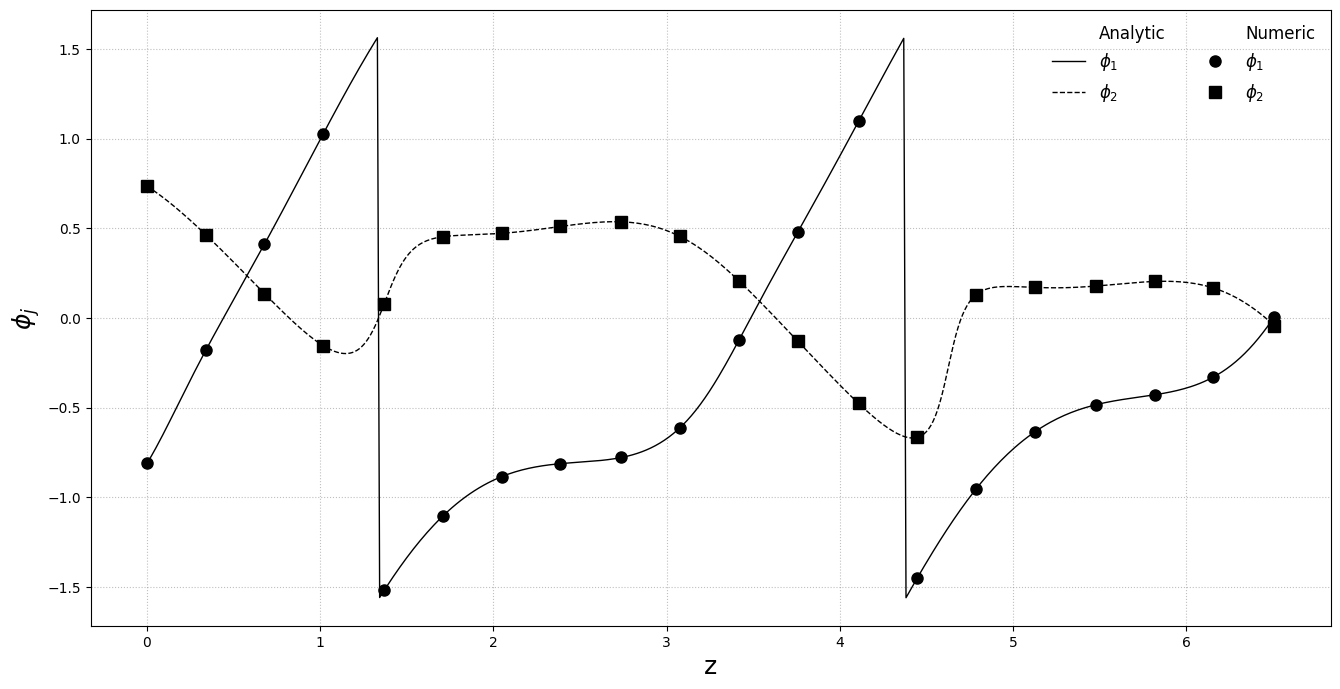

In [36]:
fig = plt.figure(figsize=(16, 8))


# Define markers for the numeric/scipy points
markers = ['o', 's']  # circle, square, triangle, diamond
analytic_linestyles = ['-', '--']   # solid, dashed, dotted, dash-dot

# Analytic plots (black, thin dashed)
case1_phi_ana_lines =[ 
    plt.plot(
        case1_z_eval[0:case1_ana_len],
        np.real(case1_phi_ana[_j]),
        linestyle=analytic_linestyles[_j],
        linewidth=1,
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, we'll handle grouping in legend
    )
    for _j in range(2)
]

# Numeric/scipy plots (black symbols, no lines, spaced out)
num_points = 20  # number of points to plot
indices = np.linspace(0, case1_scipy_len-1, num_points, dtype=int)
case1_phi_num_lines = [
    plt.plot(
        case1_z_eval[indices],
        np.real(case1_phi_nums[_j])[indices],
        linestyle='None',        # no line
        marker=markers[_j],
        markersize=8,            # slightly larger markers for visibility
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, handled in grouped legend
    )
    for _j in range(2)
]

# -------------------------
# Grouped legend
from matplotlib.lines import Line2D

legend_handles = []

# Analytic header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Analytic'))  # header placeholder
for _j, line in enumerate(case1_uv_ana_lines):
    legend_handles.append(Line2D([0], [0], color='black', lw=1, 
                                 linestyle=analytic_linestyles[_j], label=f'$\phi_{_j+1}$'))

# Numeric header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Numeric'))  # header placeholder
for _j, marker in enumerate(markers):
    legend_handles.append(Line2D([0], [0], linestyle='None', marker=marker, color='black', markersize=8,
                                 label=f'$\phi_{_j+1}$'))

case1_legend = plt.legend(handles=legend_handles, fontsize=12, ncol=2, frameon=False)

# Labels and grid (keeping your assignments)
case1_legend = plt.xlabel('z', fontsize=18)
case1_legend = plt.ylabel('$\phi_j$', fontsize=18)
case1_legend = plt.grid(True, linestyle=':', color='gray', alpha=0.5)
# plt.title('Real Parts Analytic vs Numeric Solutions (B&W)')
# plt.show()

# plt.savefig('../latex-papers/fwm-paper/plots/case1_plot_2.pdf', dpi=300, bbox_inches='tight')

## Case 2: Gauge transform

In [129]:
# -- Init values for u, v --

random_uhatj0s = [ (uhat(0, mu[_j]), u(0, mu[_j]).subs(case1_u_v_0_init_vals)) for _j in range(1, 3)]
random_vhatj0s = [ (vhat(0, mu[_j]), v(0, mu[_j]).subs(case1_u_v_0_init_vals)) for _j in range(1, 3)]
case2_u_v_0_init_vals = random_uhatj0s + random_vhatj0s

# -- Reuse params from case 1 --

case2_a_params_dict = {
    "a_2": a[2].subs(case1_a_params),
    "a_1_2": a[1, 2].subs(case1_a_params)
}
case2_init_cons_params = case1_init_cons_params
case2_lattice_and_weierstrass_args = case1_lattice_and_weierstrass_args
case2_alpha_offsets = case1_alpha_offsets

In [130]:
uhatz_sol
vhatz_sol
for _ in duhat_dvhats:
    _

Eq(uhat(z, mu[j]), sqrt(\wp'(z1, g2, g3))*sigma(z1, g2, g3)*sigma(z - 2*z0 + mu[j], g2, g3)*exp(z*beta[0] + z*r[0, j])*alphahat[j]/(sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0 + mu[j], g2, g3)*sigma(z - z0 - z1, g2, g3)*d[4]**(1/4)))

Eq(vhat(z, mu[j]), sqrt(\wp'(z1, g2, g3))*sigma(z1, g2, g3)*sigma(z - mu[j], g2, g3)*exp(-z*beta[0] - z*r[0, j])/(sqrt(wp(z1, g2, g3) - wp(-z0 + mu[j], g2, g3))*sigma(-z0 + mu[j], g2, g3)*sigma(z - z0 + z1, g2, g3)*alphahat[j]*d[4]**(1/4)))

Eq(Derivative(uhat(z, mu[1]), z), -uhat(z, mu[1])**2*vhat(z, mu[1])*b[2] + uhat(z, mu[1])*b[1]/2 + vhat(z, mu[2]))

Eq(Derivative(uhat(z, mu[2]), z), -uhat(z, mu[2])**2*vhat(z, mu[2])*b[2] + uhat(z, mu[2])*b[1]/2 + vhat(z, mu[1]))

Eq(Derivative(vhat(z, mu[1]), z), uhat(z, mu[1])*vhat(z, mu[1])**2*b[2] - uhat(z, mu[2]) - vhat(z, mu[1])*b[1]/2)

Eq(Derivative(vhat(z, mu[2]), z), -uhat(z, mu[1]) + uhat(z, mu[2])*vhat(z, mu[2])**2*b[2] - vhat(z, mu[2])*b[1]/2)

In [131]:
# Setup z array to evaluate over based on multiple periods (multiples of 2*omega1)
# We use the same lattice from case 1
case2_show_n_periods = 2
case2_z_end = abs(case2_show_n_periods * 2 * complex(case2_lattice_and_weierstrass_args["omegas"][0].rhs))
case2_n_points_z = 500
case2_z_eval = linspace(0, case2_z_end, case2_n_points_z)

# For forcing to real
real_tolerance = 1e5

In [132]:
# Solve differential equations numerically using scipy
case2_eoms = duhat_dvhats
case2_prime_vec = [_eq.rhs.subs([_.args for _ in case2_init_cons_params['params']]) for _eq in case2_eoms]
case2_uhat_symbs = [Symbol(f'_uhat{_j}_symb') for _j in range(1,3)]
case2_vhat_symbs = [Symbol(f'_vhat{_j}_symb') for _j in range(1,3)]
case2_uhat_symb_subs = [(uhat(z, mu[_j + 1]), case2_uhat_symbs[_j]) for _j in range(2)]
case2_vhat_symb_subs = [(vhat(z, mu[_j + 1]), case2_vhat_symbs[_j]) for _j in range(2)]
case2_symb_subs = case2_uhat_symb_subs + case2_vhat_symb_subs

case2_prime_symb = [_eq.subs(case2_symb_subs) for _eq in case2_prime_vec]
case_2_f_ = lambdify((z, (*case2_uhat_symbs, *case2_vhat_symbs)), case2_prime_symb)
case2_init_numeric_only = [float(re(x[1])) + float(im(x[1])) * 1j for x in case2_u_v_0_init_vals]


case2_solution = scipy.integrate.solve_ivp(
    case_2_f_, 
    (0, case2_z_end), 
    case2_init_numeric_only, 
    method='DOP853',        # 8th order method (more accurate than default RK45)
    t_eval=case2_z_eval,
    rtol=1e-10,             # Relative tolerance (default is 1e-3)
    atol=1e-12,             # Absolute tolerance (default is 1e-6)
    max_step=0.1,           # Limit step size (adjust based on z_end scale)
    dense_output=True
)

case2_sol_scipy = case2_solution.y

case2_uvhat_nums = [
    real_if_close(case2_sol_scipy[_j]*case2_sol_scipy[_j + 2], tol=real_tolerance)
    for _j in range(2)
]
case2_phi_nums = [
    real_if_close(-1.0j/2.0*np_log(case2_sol_scipy[_j]/case2_sol_scipy[_j + 2]), tol=real_tolerance)
    for _j in range(2)
]

case2_scipy_len = len(case2_uvhat_nums[0])

In [163]:
case2_kron_sol_mpmath = get_numeric_eval_of_analytic_solution_uhat_vhat_gauge(
    a_params = case2_a_params_dict,
    init_cons_params=case2_init_cons_params,
    lattice_and_weierstrass_args=case2_lattice_and_weierstrass_args,
    alpha_offsets=case2_alpha_offsets,
    z_eval_vec=case2_z_eval
)

case2_uvhat_ana = [
    real_if_close(
        case2_kron_sol_mpmath['uhat_j_evals'][_j]*case2_kron_sol_mpmath['vhat_j_evals'][_j], 
        tol=real_tolerance
    )
    for _j in range(2)
]
case2_phi_ana = [
    real_if_close(
        -1.0j/2.0*np_log(case2_kron_sol_mpmath['uhat_j_evals'][_j]/case2_kron_sol_mpmath['vhat_j_evals'][_j]), 
        tol=real_tolerance
    )
    for _j in range(2)
]

case2_ana_len = len(case2_uvhat_ana[0])

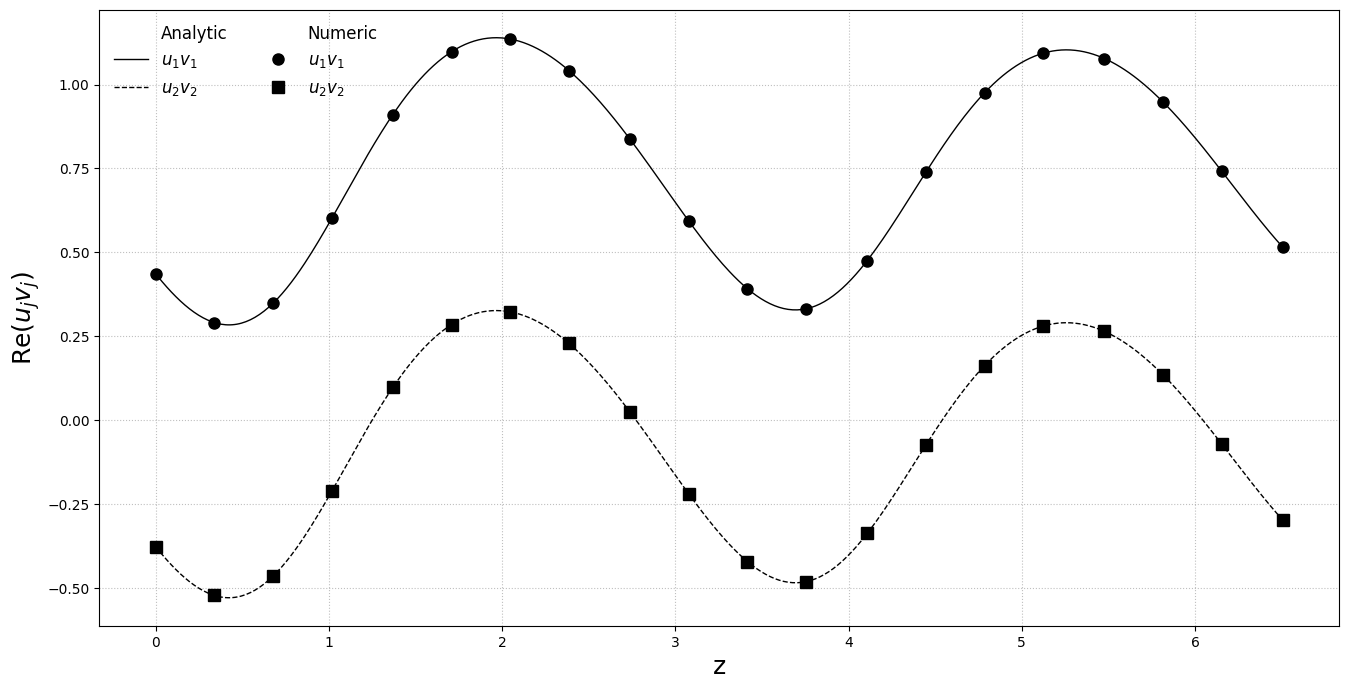

In [164]:
fig = plt.figure(figsize=(16, 8))


# Define markers for the numeric/scipy points
markers = ['o', 's']  # circle, square, triangle, diamond
analytic_linestyles = ['-', '--']   # solid, dashed, dotted, dash-dot

# Analytic plots (black, thin dashed)
case2_uv_ana_lines =[ 
    plt.plot(
        case2_z_eval[0:case2_ana_len],
        np.real(case2_uvhat_ana[_j]),
#         np.real(case1_uv_ana[_j]),
        linestyle=analytic_linestyles[_j],
        linewidth=1,
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, we'll handle grouping in legend
    )
    for _j in range(2)
]

# Numeric/scipy plots (black symbols, no lines, spaced out)
num_points = 20  # number of points to plot
indices = np.linspace(0, case2_scipy_len-1, num_points, dtype=int)
case2_uv_num_lines = [
    plt.plot(
        case2_z_eval[indices],
        np.real(case2_uvhat_nums[_j])[indices],
#         np.real(case1_uv_nums[_j])[indices],
        linestyle='None',        # no line
        marker=markers[_j],
        markersize=8,            # slightly larger markers for visibility
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, handled in grouped legend
    )
    for _j in range(2)
]

# -------------------------
# Grouped legend
from matplotlib.lines import Line2D

legend_handles = []

# Analytic header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Analytic'))  # header placeholder
for _j, line in enumerate(case2_uv_ana_lines):
    legend_handles.append(Line2D([0], [0], color='black', lw=1, 
                                 linestyle=analytic_linestyles[_j], label=f'$u_{_j+1}v_{_j+1}$'))

# Numeric header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Numeric'))  # header placeholder
for _j, marker in enumerate(markers):
    legend_handles.append(Line2D([0], [0], linestyle='None', marker=marker, color='black', markersize=8,
                                 label=f'$u_{_j+1}v_{_j+1}$'))

case2_legend = plt.legend(handles=legend_handles, fontsize=12, ncol=2, frameon=False)

# Labels and grid (keeping your assignments)
case2_legend = plt.xlabel('z', fontsize=18)
case2_legend = plt.ylabel('$\mathrm{Re}(u_jv_j)$', fontsize=18)
case2_legend = plt.grid(True, linestyle=':', color='gray', alpha=0.5)
# plt.title('Real Parts Analytic vs Numeric Solutions (B&W)')
# plt.show()

# plt.savefig('../latex-papers/fwm-paper/plots/case1_plot_1.pdf', dpi=300, bbox_inches='tight')

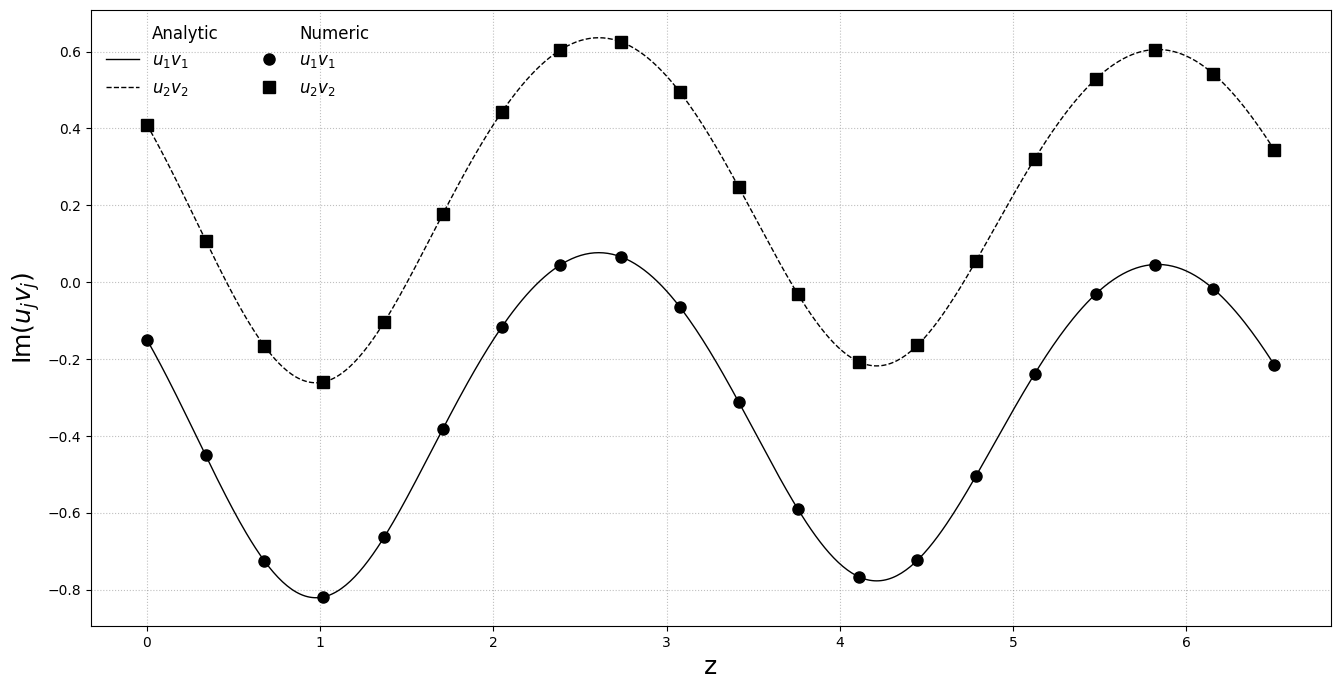

In [165]:
fig = plt.figure(figsize=(16, 8))


# Define markers for the numeric/scipy points
markers = ['o', 's']  # circle, square, triangle, diamond
analytic_linestyles = ['-', '--']   # solid, dashed, dotted, dash-dot

# Analytic plots (black, thin dashed)
case2_uv_ana_lines =[ 
    plt.plot(
        case2_z_eval[0:case1_ana_len],
        np.imag(case2_uvhat_ana[_j]),
        linestyle=analytic_linestyles[_j],
        linewidth=1,
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, we'll handle grouping in legend
    )
    for _j in range(2)
]

# Numeric/scipy plots (black symbols, no lines, spaced out)
num_points = 20  # number of points to plot
indices = np.linspace(0, case2_scipy_len-1, num_points, dtype=int)
case2_uv_num_lines = [
    plt.plot(
        case2_z_eval[indices],
        np.imag(case2_uvhat_nums[_j])[indices],
        linestyle='None',        # no line
        marker=markers[_j],
        markersize=8,            # slightly larger markers for visibility
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, handled in grouped legend
    )
    for _j in range(2)
]

# -------------------------
# Grouped legend
from matplotlib.lines import Line2D

legend_handles = []

# Analytic header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Analytic'))  # header placeholder
for _j, line in enumerate(case1_uv_ana_lines):
    legend_handles.append(Line2D([0], [0], color='black', lw=1, 
                                 linestyle=analytic_linestyles[_j], label=f'$u_{_j+1}v_{_j+1}$'))

# Numeric header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Numeric'))  # header placeholder
for _j, marker in enumerate(markers):
    legend_handles.append(Line2D([0], [0], linestyle='None', marker=marker, color='black', markersize=8,
                                 label=f'$u_{_j+1}v_{_j+1}$'))

case2_legend = plt.legend(handles=legend_handles, fontsize=12, ncol=2, frameon=False)

# Labels and grid (keeping your assignments)
case2_legend = plt.xlabel('z', fontsize=18)
case2_legend = plt.ylabel('$\mathrm{Im}(u_jv_j)$', fontsize=18)
case2_legend = plt.grid(True, linestyle=':', color='gray', alpha=0.5)
# plt.title('Real Parts Analytic vs Numeric Solutions (B&W)')
# plt.show()

# plt.savefig('../latex-papers/fwm-paper/plots/case1_plot_2.pdf', dpi=300, bbox_inches='tight')

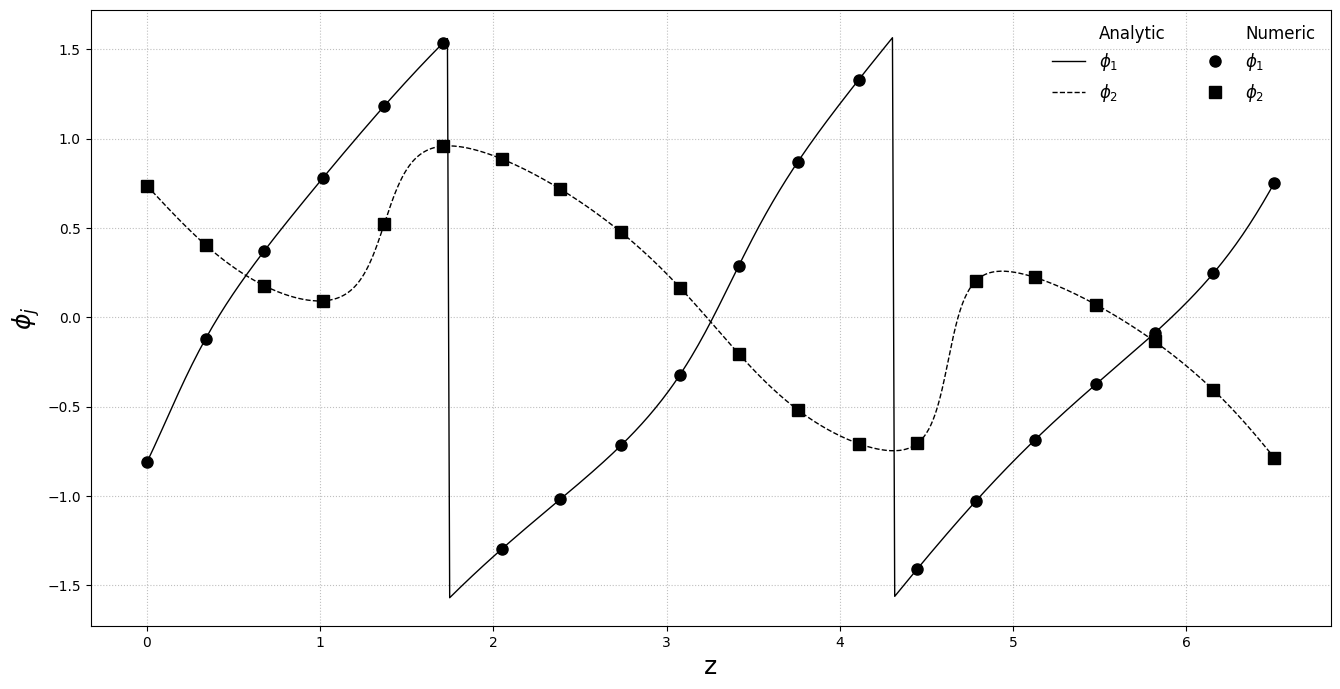

In [166]:
fig = plt.figure(figsize=(16, 8))


# Define markers for the numeric/scipy points
markers = ['o', 's']  # circle, square, triangle, diamond
analytic_linestyles = ['-', '--']   # solid, dashed, dotted, dash-dot

# Analytic plots (black, thin dashed)
case2_phi_ana_lines =[ 
    plt.plot(
        case2_z_eval[0:case1_ana_len],
        np.real(case2_phi_ana[_j]),
        linestyle=analytic_linestyles[_j],
        linewidth=1,
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, we'll handle grouping in legend
    )
    for _j in range(2)
]

# Numeric/scipy plots (black symbols, no lines, spaced out)
num_points = 20  # number of points to plot
indices = np.linspace(0, case2_scipy_len-1, num_points, dtype=int)
case2_phi_num_lines = [
    plt.plot(
        case2_z_eval[indices],
        np.real(case2_phi_nums[_j])[indices],
        linestyle='None',        # no line
        marker=markers[_j],
        markersize=8,            # slightly larger markers for visibility
        color='black',
        label=f'$u_{_j+1} v_{_j+1}$'  # simplified, handled in grouped legend
    )
    for _j in range(2)
]

# -------------------------
# Grouped legend
from matplotlib.lines import Line2D

legend_handles = []

# Analytic header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Analytic'))  # header placeholder
for _j, line in enumerate(case1_uv_ana_lines):
    legend_handles.append(Line2D([0], [0], color='black', lw=1, 
                                 linestyle=analytic_linestyles[_j], label=f'$\phi_{_j+1}$'))

# Numeric header
legend_handles.append(Line2D([0], [0], color='white', linestyle='None', label='Numeric'))  # header placeholder
for _j, marker in enumerate(markers):
    legend_handles.append(Line2D([0], [0], linestyle='None', marker=marker, color='black', markersize=8,
                                 label=f'$\phi_{_j+1}$'))

case2_legend = plt.legend(handles=legend_handles, fontsize=12, ncol=2, frameon=False)

# Labels and grid (keeping your assignments)
case2_legend = plt.xlabel('z', fontsize=18)
case2_legend = plt.ylabel('$\phi_j$', fontsize=18)
case2_legend = plt.grid(True, linestyle=':', color='gray', alpha=0.5)
# plt.title('Real Parts Analytic vs Numeric Solutions (B&W)')
# plt.show()

# plt.savefig('../latex-papers/fwm-paper/plots/case1_plot_2.pdf', dpi=300, bbox_inches='tight')